In [194]:
from ultralytics import YOLO
import os
import numpy as np
import pandas as pd
from pathlib import Path
from tqdm import tqdm
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import cv2
import random
from sklearn.metrics import roc_auc_score


In [195]:
# ---------- bbox helpers ----------

def calculate_iou(box1, box2):
    """box format: [x1, y1, x2, y2]"""
    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])
    x2 = min(box1[2], box2[2])
    y2 = min(box1[3], box2[3])
    inter = max(0, x2 - x1) * max(0, y2 - y1)
    a1 = (box1[2] - box1[0]) * (box1[3] - box1[1])
    a2 = (box2[2] - box2[0]) * (box2[3] - box2[1])
    union = a1 + a2 - inter
    return inter / union if union > 0 else 0.0


def yolo_to_xyxy(yolo_box, img_width, img_height):
    """YOLO 歸一化 [cx, cy, w, h] -> [x1, y1, x2, y2]"""
    cx, cy, w, h = yolo_box
    return [
        (cx - w / 2) * img_width,
        (cy - h / 2) * img_height,
        (cx + w / 2) * img_width,
        (cy + h / 2) * img_height,
    ]


def box_center(box):
    return np.array([(box[0] + box[2]) / 2, (box[1] + box[3]) / 2])


def greedy_nms(boxes, scores, iou_threshold):
    """Greedy NMS. Returns indices of kept boxes."""
    if not boxes:
        return []
    boxes  = np.array(boxes)
    scores = np.array(scores)
    order  = scores.argsort()[::-1]
    kept, suppressed = [], set()
    for i in [int(x) for x in order]:
        if i in suppressed:
            continue
        kept.append(i)
        for j in [int(x) for x in order]:
            if j == i or j in suppressed:
                continue
            if calculate_iou(boxes[i], boxes[j]) >= iou_threshold:
                suppressed.add(j)
    return kept


# ---------- GT loading ----------

def load_gt_boxes(od_image_path, img_width, img_height):
    """Load GT bounding boxes from OD-format label file."""
    label_path = (
        od_image_path
        .replace('/images/', '/labels/')
        .replace('.png', '.txt')
        .replace('.jpg', '.txt')
    )
    gt_nodule, gt_maybe = [], []
    if Path(label_path).exists():
        with open(label_path) as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) < 5:
                    continue
                class_id = int(float(parts[0]))
                xyxy = yolo_to_xyxy(list(map(float, parts[1:5])), img_width, img_height)
                if class_id == 0:
                    gt_nodule.append(xyxy)
                elif class_id == 1:
                    gt_maybe.append(xyxy)
    return gt_nodule, gt_maybe


# ---------- extract predictions ----------

def extract_nodule_preds(result):
    """Extract class-0 predictions as list of {'box', 'conf'}."""
    preds = []
    if result.boxes is not None and len(result.boxes) > 0:
        cls_arr  = result.boxes.cls.cpu().numpy()
        xyxy_arr = result.boxes.xyxy.cpu().numpy()
        conf_arr = result.boxes.conf.cpu().numpy()
        for i, cls in enumerate(cls_arr):
            if int(cls) == 0:
                preds.append({'box': xyxy_arr[i].tolist(), 'conf': float(conf_arr[i])})
    return preds

In [196]:
def fuse_predictions(od_result, seg_result, strategy='or', nms_iou=0.5):
    """
    Fuse predictions from OD and Seg models.

    strategy:
      'or'  - 聯集: 兩個模型的預測框全部合併，再做 greedy NMS
      'and' - 交集: 只保留兩個模型都同意的框（IoU >= nms_iou），
               框取平均座標，conf 取平均

    Returns list of {'box': [x1,y1,x2,y2], 'conf': float, 'source': str}
    """
    od_preds  = extract_nodule_preds(od_result)
    seg_preds = extract_nodule_preds(seg_result)

    if strategy == 'or':
        all_boxes = [p['box']  for p in od_preds + seg_preds]
        all_confs = [p['conf'] for p in od_preds + seg_preds]
        all_srcs  = ['od'] * len(od_preds) + ['seg'] * len(seg_preds)
        if not all_boxes:
            return []
        kept = greedy_nms(all_boxes, all_confs, nms_iou)
        return [{'box': all_boxes[k], 'conf': all_confs[k], 'source': all_srcs[k]}
                for k in kept]

    elif strategy == 'and':
        fused = []
        matched_seg = set()
        for i, op in enumerate(od_preds):
            best_iou, best_j = 0, -1
            for j, sp in enumerate(seg_preds):
                if j in matched_seg:
                    continue
                iou = calculate_iou(op['box'], sp['box'])
                if iou > best_iou:
                    best_iou, best_j = iou, j
            if best_iou >= nms_iou:
                matched_seg.add(best_j)
                sp = seg_preds[best_j]
                avg_conf   = (op['conf'] + sp['conf']) / 2
                merged_box = [(op['box'][k] + sp['box'][k]) / 2 for k in range(4)]
                fused.append({'box': merged_box, 'conf': avg_conf, 'source': 'both'})
        return fused

    else:
        raise ValueError(f"Unknown strategy: '{strategy}'. Use 'or' or 'and'.")

In [197]:
def match_and_build_records(pred_entries, gt_nodule, gt_maybe,
                             patient_id, file_name, iou_threshold):
    """
    pred_entries : list of {'box': [x1,y1,x2,y2], 'conf': float}
    Returns list of record dicts (TP / FP / FN / TN).
    """
    matched_gt   = set()
    matched_pred = set()
    ignored_pred = set()
    matched_pairs = []

    for i, pred in enumerate(pred_entries):
        best_iou, best_j = 0, -1
        for j, gt_box in enumerate(gt_nodule):
            if j in matched_gt:
                continue
            iou = calculate_iou(pred['box'], gt_box)
            if iou > best_iou:
                best_iou, best_j = iou, j

        if best_iou >= iou_threshold:
            matched_gt.add(best_j)
            matched_pred.add(i)
            matched_pairs.append((i, best_j, best_iou))
        else:
            maybe_iou = max(
                (calculate_iou(pred['box'], gb) for gb in gt_maybe), default=0
            )
            if maybe_iou >= iou_threshold:
                ignored_pred.add(i)

    records = []
    base = {'patient_ID': patient_id, 'file_name': file_name}

    for pred_i, gt_j, iou in matched_pairs:
        pb, gb = pred_entries[pred_i]['box'], gt_nodule[gt_j]
        records.append({**base,
            'match_type': 'TP', 'pred_box': pb, 'gt_box': gb,
            'iou': iou,
            'conf': pred_entries[pred_i]['conf'],
            'center_distance': float(np.linalg.norm(box_center(pb) - box_center(gb))),
            'source': pred_entries[pred_i].get('source', ''),
        })

    for i, pred in enumerate(pred_entries):
        if i not in matched_pred and i not in ignored_pred:
            records.append({**base,
                'match_type': 'FP', 'pred_box': pred['box'], 'gt_box': None,
                'iou': 0.0, 'conf': pred['conf'], 'center_distance': None,
                'source': pred.get('source', ''),
            })

    for j, gb in enumerate(gt_nodule):
        if j not in matched_gt:
            records.append({**base,
                'match_type': 'FN', 'pred_box': None, 'gt_box': gb,
                'iou': 0.0, 'conf': None, 'center_distance': None, 'source': None,
            })

    if not records:
        records.append({**base,
            'match_type': 'TN',
            'pred_box': None, 'gt_box': None,
            'iou': None, 'conf': None, 'center_distance': None, 'source': None,
        })
    return records


def get_records(od_result, seg_result, od_image_path,
                strategy, patient_id, iou_threshold, nms_iou):
    """
    strategy: 'od_only' | 'seg_only' | 'or' | 'and'
    GT is always loaded from OD-format label (bbox).
    """
    img_height, img_width = od_result.orig_shape
    gt_nodule, gt_maybe  = load_gt_boxes(od_image_path, img_width, img_height)
    file_name = Path(od_image_path).name

    if strategy == 'od_only':
        preds = extract_nodule_preds(od_result)
    elif strategy == 'seg_only':
        preds = extract_nodule_preds(seg_result)
    else:  # 'or' / 'and'
        preds = fuse_predictions(od_result, seg_result,
                                  strategy=strategy, nms_iou=nms_iou)

    return match_and_build_records(preds, gt_nodule, gt_maybe,
                                    patient_id, file_name, iou_threshold)

In [198]:
def compute_metrics_from_counts(tp, fp, fn):
    eta = 1e-9
    recall    = tp / (tp + fn + eta)
    precision = tp / (tp + fp + eta)
    f1        = 2 * precision * recall / (precision + recall + eta)
    return recall, precision, f1


def compute_nodule_metrics(df):
    """
    Global nodule-level metrics (no per-image averaging).
    Counts all TP/FP/FN across the entire dataset.
    """
    tp = (df['match_type'] == 'TP').sum()
    fp = (df['match_type'] == 'FP').sum()
    fn = (df['match_type'] == 'FN').sum()
    sensitivity, ppv, f1 = compute_metrics_from_counts(tp, fp, fn)
    return dict(tp=int(tp), fp=int(fp), fn=int(fn),
                sensitivity=sensitivity, ppv=ppv, f1=f1)


def compute_image_binary_metrics(df):
    """
    Image-level binary classification: nodule present (1) or absent (0).
      TP: image has GT nodule  AND model predicted at least one
      FP: image has no GT      AND model predicted at least one
      FN: image has GT nodule  AND model predicted nothing
      TN: image has no GT      AND model predicted nothing
    Score for AUC = max prediction confidence in that image.
    """
    per_img = df.groupby('file_name').apply(lambda g: pd.Series({
        'has_gt':   g['match_type'].isin(['TP', 'FN']).any(),
        'has_pred': g['match_type'].isin(['TP', 'FP']).any(),
        'max_conf': g.loc[g['match_type'].isin(['TP', 'FP']), 'conf'].max(),
    })).reset_index()
    per_img['max_conf'] = per_img['max_conf'].fillna(0.0)
    per_img['gt_label'] = per_img['has_gt'].astype(int)
    tp = int(( per_img['has_gt'] &  per_img['has_pred']).sum())
    fp = int((~per_img['has_gt'] &  per_img['has_pred']).sum())
    fn = int(( per_img['has_gt'] & ~per_img['has_pred']).sum())
    tn = int((~per_img['has_gt'] & ~per_img['has_pred']).sum())
    eta = 1e-9
    sensitivity = tp / (tp + fn + eta)
    specificity = tn / (tn + fp + eta)
    ppv         = tp / (tp + fp + eta)
    npv         = tn / (tn + fn + eta)
    f1          = 2 * ppv * sensitivity / (ppv + sensitivity + eta)
    acc         = (tp + tn) / (tp + tn + fp + fn + eta)
    auc = float(roc_auc_score(per_img['gt_label'], per_img['max_conf'])) \
          if per_img['gt_label'].nunique() == 2 else float('nan')
    return dict(tp=tp, fp=fp, fn=fn, tn=tn,
                sensitivity=sensitivity, specificity=specificity,
                ppv=ppv, npv=npv, f1=f1, acc=acc, auc=auc)


def compute_patient_binary_metrics(df):
    """
    Patient-level binary classification: patient has nodule (1) or absent (0).
    Score for AUC = max prediction confidence across all images of that patient.
    """
    per_pat = df.groupby('patient_ID').apply(lambda g: pd.Series({
        'has_gt':   g['match_type'].isin(['TP', 'FN']).any(),
        'has_pred': g['match_type'].isin(['TP', 'FP']).any(),
        'max_conf': g.loc[g['match_type'].isin(['TP', 'FP']), 'conf'].max(),
    })).reset_index()
    per_pat['max_conf'] = per_pat['max_conf'].fillna(0.0)
    per_pat['gt_label'] = per_pat['has_gt'].astype(int)
    tp = int(( per_pat['has_gt'] &  per_pat['has_pred']).sum())
    fp = int((~per_pat['has_gt'] &  per_pat['has_pred']).sum())
    fn = int(( per_pat['has_gt'] & ~per_pat['has_pred']).sum())
    tn = int((~per_pat['has_gt'] & ~per_pat['has_pred']).sum())
    eta = 1e-9
    sensitivity = tp / (tp + fn + eta)
    specificity = tn / (tn + fp + eta)
    ppv         = tp / (tp + fp + eta)
    npv         = tn / (tn + fn + eta)
    f1          = 2 * ppv * sensitivity / (ppv + sensitivity + eta)
    acc         = (tp + tn) / (tp + tn + fp + fn + eta)
    auc = float(roc_auc_score(per_pat['gt_label'], per_pat['max_conf'])) \
          if per_pat['gt_label'].nunique() == 2 else float('nan')
    return dict(tp=tp, fp=fp, fn=fn, tn=tn,
                sensitivity=sensitivity, specificity=specificity,
                ppv=ppv, npv=npv, f1=f1, acc=acc, auc=auc)


def summarize(df, label=''):
    nod = compute_nodule_metrics(df)
    img = compute_image_binary_metrics(df)
    pat = compute_patient_binary_metrics(df)
    tag = f"[{label}] " if label else "  "
    print(f"{tag}Nodule-level  | sensitivity={nod['sensitivity']:.4f}  ppv={nod['ppv']:.4f}  f1={nod['f1']:.4f}")
    print(f"{tag}Image-level   | sensitivity={img['sensitivity']:.4f}  specificity={img['specificity']:.4f}  "
          f"ppv={img['ppv']:.4f}  npv={img['npv']:.4f}  acc={img['acc']:.4f}  auc={img['auc']:.4f}")
    print(f"{tag}Patient-level | sensitivity={pat['sensitivity']:.4f}  specificity={pat['specificity']:.4f}  "
          f"ppv={pat['ppv']:.4f}  npv={pat['npv']:.4f}  acc={pat['acc']:.4f}  auc={pat['auc']:.4f}")
    tp_iou = df.loc[df['match_type'] == 'TP', 'iou'].dropna()
    if len(tp_iou):
        print(f"{tag}TP IoU        | n={len(tp_iou)}  mean={tp_iou.mean():.4f}  "
              f"median={tp_iou.median():.4f}  std={tp_iou.std():.4f}")
    tp_cd = df.loc[df['match_type'] == 'TP', 'center_distance'].dropna()
    if len(tp_cd):
        print(f"{tag}Center dist   | n={len(tp_cd)}  mean={tp_cd.mean():.2f}  "
              f"median={tp_cd.median():.2f}  max={tp_cd.max():.2f}")


def calculate_ap(df):
    """101-point interpolated AP (COCO style)."""
    total_gt = df['match_type'].isin(['TP', 'FN']).sum()
    if total_gt == 0:
        return 0.0, np.array([]), np.array([])
    preds = (
        df[df['match_type'].isin(['TP', 'FP'])].dropna(subset=['conf'])
        .sort_values('conf', ascending=False).reset_index(drop=True)
    )
    if len(preds) == 0:
        return 0.0, np.array([0.0]), np.array([0.0])
    tp_cs = (preds['match_type'] == 'TP').cumsum().values
    fp_cs = (preds['match_type'] == 'FP').cumsum().values
    recalls    = tp_cs / total_gt
    precisions = tp_cs / (tp_cs + fp_cs)
    ap = 0.0
    for thr in np.linspace(0, 1, 101):
        p = precisions[recalls >= thr]
        ap += p.max() if len(p) > 0 else 0.0
    return ap / 101, recalls, precisions


In [199]:
data_root = "/Users/tony.tu/Desktop/戴承智慧/thyroid"

In [227]:
od_name  = "2026_03_11(1)"
seg_name = "2026_03_12(1)"

od_model  = YOLO(f'{data_root}/yolo_output/runs/detect/{od_name}/weights/best.pt')
seg_model = YOLO(f'{data_root}/yolo_output/runs/seg/{seg_name}/weights/best.pt')

print(f"OD  model: {od_name}")
print(f"Seg model: {seg_name}")

OD  model: 2026_03_11(1)
Seg model: 2026_03_12(1)


In [228]:
data_df = pd.read_csv(f'{data_root}/yolo_data/all_csv_files/combined_dataset_info_v5.csv')

# val_df = data_df[
#     (data_df['dataset'] == 'CG') &
#     (data_df['train_or_test'] == 'test') &
#     (data_df['nodule_type'] != 'none')
# ]
val_df = data_df[
    (data_df['dataset'] == 'CG') &
    (data_df['train_or_test'] == 'test')
]
od_root  = f'{data_root}/yolo_data/all_data_nodule_normal_cut_od/images'
seg_root = f'{data_root}/yolo_data/all_data_nodule_normal_cut_seg/images'

od_file_list  = [os.path.join(od_root,  f"{fn}.png") for fn in val_df['file_name']]
seg_file_list = [os.path.join(seg_root, f"{fn}.png") for fn in val_df['file_name']]
pid_list      = val_df['patient_ID'].tolist()

print(f"Total images: {len(od_file_list)}")

Total images: 2364


In [229]:

# od_root  = f'{data_root}/yolo_data/ThyroidXL_data/test_od/images'
# seg_root = f'{data_root}/yolo_data/ThyroidXL_data/test_seg/images'
# image_name_od_dir = os.listdir(od_root)
# image_name_seg_dir = os.listdir(seg_root)


# od_file_list  = [os.path.join(od_root,  f"{fn}") for fn in image_name_od_dir]
# seg_file_list = [os.path.join(seg_root, f"{fn}") for fn in image_name_seg_dir]
# pid_list      = [f"{fn.split("_")[0]}" for fn in image_name_od_dir]

# print(f"Total images: {len(od_file_list)}")

In [230]:
import torch

device         = "mps"
conf_threshold = 0.5
batch_size     = 32

print(f"Using device: {device}")

# --- OD inference ---
od_raw = []   # (od_image_path, pid, od_result)
for i in tqdm(range(0, len(od_file_list), batch_size), desc="OD  Inference"):
    batch_paths = od_file_list[i:i + batch_size]
    batch_pids  = pid_list[i:i + batch_size]
    for path, pid, res in zip(
        batch_paths, batch_pids,
        od_model(batch_paths, conf=conf_threshold, verbose=False, device=device)
    ):
        od_raw.append((path, pid, res))

# --- Seg inference ---
seg_raw = []  # (seg_image_path, pid, seg_result)
for i in tqdm(range(0, len(seg_file_list), batch_size), desc="Seg Inference"):
    batch_paths = seg_file_list[i:i + batch_size]
    batch_pids  = pid_list[i:i + batch_size]
    for path, pid, res in zip(
        batch_paths, batch_pids,
        seg_model(batch_paths, conf=conf_threshold, verbose=False, device=device)
    ):
        seg_raw.append((path, pid, res))

print(f"OD  inference done: {len(od_raw)} images")
print(f"Seg inference done: {len(seg_raw)} images")

Using device: mps


Seg Inference: 100%|██████████| 74/74 [01:03<00:00,  1.17it/s]

OD  inference done: 2364 images
Seg inference done: 2364 images


In [231]:
# --- 評估設定 ---
strategies            = ['od_only', 'seg_only', 'or', 'and']
nms_iou               = 0.5   # 融合時 NMS / AND 判斷用的 IoU 門檻
iou_thresholds_report = [0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
iou_thresholds_map    = list(np.round(np.arange(0.5, 1.0, 0.05), 2))
all_iou_thresholds    = sorted(set(iou_thresholds_report + iou_thresholds_map))

# results_by_strategy_iou[strategy][iou_threshold] = DataFrame
results_by_strategy_iou = {s: {} for s in strategies}

for iou_threshold in tqdm(all_iou_thresholds, desc="Matching"):
    for strategy in strategies:
        all_records = []
        for (od_path, pid, od_res), (_, _, seg_res) in zip(od_raw, seg_raw):
            records = get_records(
                od_res, seg_res, od_path,
                strategy=strategy,
                patient_id=pid,
                iou_threshold=iou_threshold,
                nms_iou=nms_iou,
            )
            all_records.extend(records)
        results_by_strategy_iou[strategy][iou_threshold] = pd.DataFrame(all_records)

# --- 印出 report thresholds ---
strategy_labels = {
    'od_only':  'OD only',
    'seg_only': 'Seg only (bbox)',
    'or':       'Fusion OR (union)',
    'and':      'Fusion AND (intersection)',
}

for iou_threshold in iou_thresholds_report:
    print(f"\n{'='*60}")
    print(f"IoU threshold = {iou_threshold}")
    print('='*60)
    for strategy in strategies:
        print(f"  --- {strategy_labels[strategy]} ---")
        summarize(results_by_strategy_iou[strategy][iou_threshold])

Matching:   0%|          | 0/12 [00:00<?, ?it/s]

Matching: 100%|██████████| 12/12 [00:57<00:00,  4.82s/it]



IoU threshold = 0.3
  --- OD only ---


/var/folders/52/nxxlf7js5vv8b4p_73c32whw0000gn/T/ipykernel_84922/2441402943.py:31: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  per_img = df.groupby('file_name').apply(lambda g: pd.Series({
/var/folders/52/nxxlf7js5vv8b4p_73c32whw0000gn/T/ipykernel_84922/2441402943.py:61: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  per_pat = df.groupby('patient_ID').apply(lambda g: pd.Series({


  Nodule-level  | sensitivity=0.8913  ppv=0.9839  f1=0.9353
  Image-level   | sensitivity=0.9543  specificity=1.0000  ppv=1.0000  npv=0.9331  acc=0.9721  auc=0.9771
  Patient-level | sensitivity=0.9828  specificity=1.0000  ppv=1.0000  npv=0.9679  acc=0.9887  auc=0.9914
  TP IoU        | n=1402  mean=0.8613  median=0.8828  std=0.0927
  Center dist   | n=1402  mean=3.72  median=2.35  max=91.38
  --- Seg only (bbox) ---


...

/var/folders/52/nxxlf7js5vv8b4p_73c32whw0000gn/T/ipykernel_84922/2441402943.py:31: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  per_img = df.groupby('file_name').apply(lambda g: pd.Series({
/var/folders/52/nxxlf7js5vv8b4p_73c32whw0000gn/T/ipykernel_84922/2441402943.py:61: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  per_pat = df.groupby('patient_ID').apply(lambda g: pd.Series({


  Nodule-level  | sensitivity=0.3338  ppv=0.3659  f1=0.3491
  Image-level   | sensitivity=0.9570  specificity=0.9989  ppv=0.9993  npv=0.9369  acc=0.9734  auc=0.9782
  Patient-level | sensitivity=0.9803  specificity=0.9953  ppv=0.9975  npv=0.9633  acc=0.9854  auc=0.9895
  TP IoU        | n=525  mean=0.9317  median=0.9296  std=0.0207
  Center dist   | n=525  mean=2.34  median=1.83  max=10.61
  --- Fusion OR (union) ---


/var/folders/52/nxxlf7js5vv8b4p_73c32whw0000gn/T/ipykernel_84922/2441402943.py:31: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  per_img = df.groupby('file_name').apply(lambda g: pd.Series({
/var/folders/52/nxxlf7js5vv8b4p_73c32whw0000gn/T/ipykernel_84922/2441402943.py:61: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  per_pat = df.groupby('patient_ID').apply(lambda g: pd.Series({


  Nodule-level  | sensitivity=0.3490  ppv=0.3672  f1=0.3579
  Image-level   | sensitivity=0.9778  specificity=0.9978  ppv=0.9986  npv=0.9664  acc=0.9856  auc=0.9884
  Patient-level | sensitivity=0.9901  specificity=0.9953  ppv=0.9975  npv=0.9813  acc=0.9919  auc=0.9948
  TP IoU        | n=549  mean=0.9313  median=0.9281  std=0.0204
  Center dist   | n=549  mean=2.34  median=1.86  max=13.54
  --- Fusion AND (intersection) ---
  Nodule-level  | sensitivity=0.3643  ppv=0.4186  f1=0.3895
  Image-level   | sensitivity=0.9300  specificity=1.0000  ppv=1.0000  npv=0.9012  acc=0.9573  auc=0.9650
  Patient-level | sensitivity=0.9729  specificity=1.0000  ppv=1.0000  npv=0.9505  acc=0.9822  auc=0.9865
  TP IoU        | n=573  mean=0.9315  median=0.9304  std=0.0208
  Center dist   | n=573  mean=2.26  median=1.76  max=12.53


/var/folders/52/nxxlf7js5vv8b4p_73c32whw0000gn/T/ipykernel_84922/2441402943.py:31: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  per_img = df.groupby('file_name').apply(lambda g: pd.Series({
/var/folders/52/nxxlf7js5vv8b4p_73c32whw0000gn/T/ipykernel_84922/2441402943.py:61: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  per_pat = df.groupby('patient_ID').apply(lambda g: pd.Series({


In [232]:
rows = []

for strategy in strategies:
    # mAP@[0.5:0.95]
    aps_map = [calculate_ap(results_by_strategy_iou[strategy][iou])[0]
               for iou in iou_thresholds_map]
    mAP = float(np.mean(aps_map))

    for iou_threshold in iou_thresholds_report:
        ndf = results_by_strategy_iou[strategy][iou_threshold]

        ap, _, _  = calculate_ap(ndf)
        nod       = compute_nodule_metrics(ndf)
        img       = compute_image_binary_metrics(ndf)
        pat       = compute_patient_binary_metrics(ndf)
        tp_iou    = ndf.loc[ndf['match_type'] == 'TP', 'iou'].dropna()
        tp_cd     = ndf.loc[ndf['match_type'] == 'TP', 'center_distance'].dropna()

        rows.append({
            'strategy':       strategy_labels[strategy],
            'iou_threshold':  iou_threshold,
            # ── Detection (nodule-level) ──────────────────────────
            'AP':             round(ap,  4),
            'mAP@0.5:0.95':  round(mAP, 4),
            'nod_sensitivity': round(nod['sensitivity'], 4),   # = Recall
            'nod_ppv':         round(nod['ppv'],         4),   # = Precision
            'nod_f1':          round(nod['f1'],          4),
            # ── Localisation quality (TP boxes only) ─────────────
            'iou_mean':       round(tp_iou.mean(),   4) if len(tp_iou) > 0 else None,
            'iou_median':     round(tp_iou.median(), 4) if len(tp_iou) > 0 else None,
            'cd_mean':        round(tp_cd.mean(),    2) if len(tp_cd)  > 0 else None,
            'cd_median':      round(tp_cd.median(),  2) if len(tp_cd)  > 0 else None,
            'cd_max':         round(tp_cd.max(),     2) if len(tp_cd)  > 0 else None,
            # ── Image-level binary classification ─────────────────
            'img_sensitivity': round(img['sensitivity'], 4),
            'img_specificity': round(img['specificity'], 4),
            'img_ppv':         round(img['ppv'],         4),
            'img_npv':         round(img['npv'],         4),
            'img_f1':          round(img['f1'],          4),
            'img_acc':         round(img['acc'],         4),
            'img_auc':         round(img['auc'],         4) if not pd.isna(img['auc']) else None,
            # ── Patient-level binary classification ───────────────
            'pat_sensitivity': round(pat['sensitivity'], 4),
            'pat_specificity': round(pat['specificity'], 4),
            'pat_ppv':         round(pat['ppv'],         4),
            'pat_npv':         round(pat['npv'],         4),
            'pat_f1':          round(pat['f1'],          4),
            'pat_acc':         round(pat['acc'],         4),
            'pat_auc':         round(pat['auc'],         4) if not pd.isna(pat['auc']) else None,
        })

summary_df = pd.DataFrame(rows).set_index(['strategy', 'iou_threshold'])
display(summary_df)


/var/folders/52/nxxlf7js5vv8b4p_73c32whw0000gn/T/ipykernel_84922/2441402943.py:31: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  per_img = df.groupby('file_name').apply(lambda g: pd.Series({
/var/folders/52/nxxlf7js5vv8b4p_73c32whw0000gn/T/ipykernel_84922/2441402943.py:61: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  per_pat = df.groupby('patient_ID').apply(lambda g: pd.Series({
/var/folders/52/nxxlf7js5vv8b4p_73c32

AP  mAP@0.5:0.95  \
strategy                  iou_threshold                         
OD only                   0.3            0.8898        0.6506   
                          0.4            0.8787        0.6506   
                          0.5            0.8669        0.6506   
                          0.6            0.8655        0.6506   
                          0.7            0.8300        0.6506   
                          0.8            0.6825        0.6506   
                          0.9            0.2377        0.6506   
Seg only (bbox)           0.3            0.8781        0.6439   
                          0.4            0.8766        0.6439   
                          0.5            0.8650        0.6439   
                          0.6            0.8529        0.6439   
                          0.7            0.8252        0.6439   
                          0.8            0.6649        0.6439   
                          0.9            0.2295        0.6439   
Fusion OR (union)         0.3            0.9084        0.6668   
                          0.4            0.9068        0.6668   
                          0.5            0.8950        0.6668   
                          0.6            0.8842        0.6668   
                          0.7            0.8478        0.6668   
                          0.8            0.6892        0.6668   
                          0.9            0.2369        0.6668   
Fusion AND (intersection) 0.3            0.8606        0.6413   
                          0.4            0.8493        0.6413   
                          0.5            0.8474        0.6413   
                          0.6            0.8359        0.6413   
                          0.7            0.8109        0.6413   
                          0.8            0.6810        0.6413   
                          0.9            0.2625        0.6413   

                                         nod_sensitivity  nod_ppv  nod_f1  \
strategy                  iou_threshold                                     
OD only                   0.3                     0.8913   0.9839  0.9353   
                          0.4                     0.8862   0.9782  0.9300   
                          0.5                     0.8798   0.9712  0.9233   
                          0.6                     0.8722   0.9628  0.9153   
                          0.7                     0.8455   0.9327  0.8870   
                          0.8                     0.7400   0.8123  0.7745   
                          0.9                     0.3528   0.3849  0.3682   
Seg only (bbox)           0.3                     0.8862   0.9817  0.9315   
                          0.4                     0.8830   0.9782  0.9282   
                          0.5                     0.8779   0.9725  0.9228   
                          0.6                     0.8697   0.9627  0.9138   
                          0.7                     0.8449   0.9346  0.8875   
                          0.8                     0.7228   0.7990  0.7590   
                          0.9                     0.3338   0.3659  0.3491   
Fusion OR (union)         0.3                     0.9154   0.9783  0.9458   
                          0.4                     0.9116   0.9742  0.9419   
                          0.5                     0.9053   0.9674  0.9353   
                          0.6                     0.8989   0.9599  0.9284   
                          0.7                     0.8678   0.9261  0.8960   
                          0.8                     0.7495   0.7961  0.7721   
                          0.9                     0.3490   0.3672  0.3579   
Fusion AND (intersection) 0.3                     0.8608   0.9956  0.9233   
                          0.4                     0.8563   0.9904  0.9185   
                          0.5                     0.8519   0.9853  0.9137   
                          0.6                     0.8455   0.9779  0.9069   
               

In [233]:
out_dir = f'{data_root}/yolo_output/ensemble_{od_name}__{seg_name}'
os.makedirs(out_dir, exist_ok=True)
summary_df.to_csv(os.path.join(out_dir, 'ensemble_metrics.csv'))
print(f"Saved to {out_dir}/ensemble_metrics.csv")

Saved to /Users/tony.tu/Desktop/戴承智慧/thyroid/yolo_output/ensemble_2026_03_11(1)__2026_03_12(1)/ensemble_metrics.csv


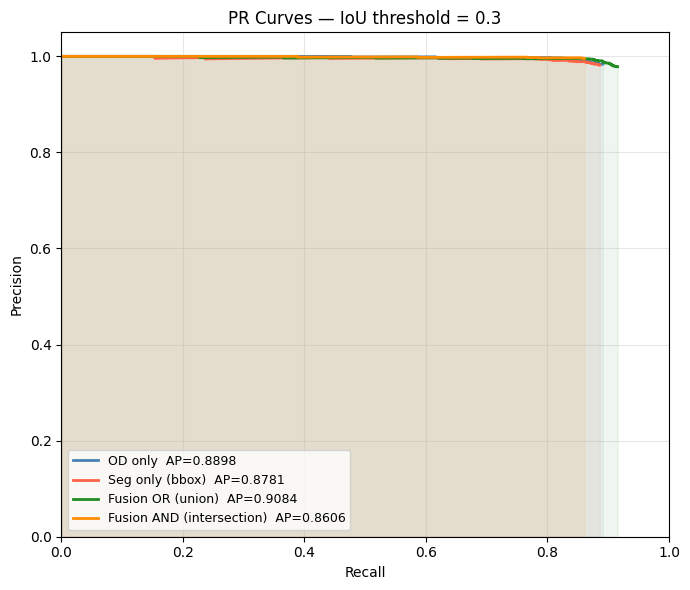

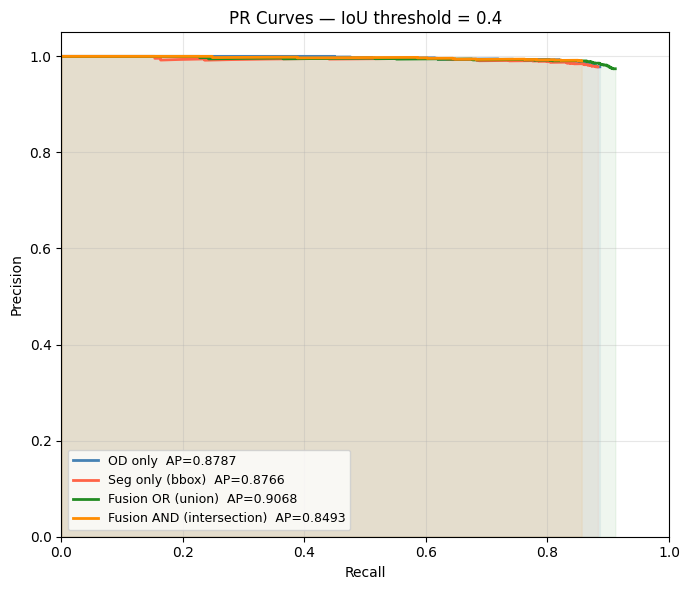

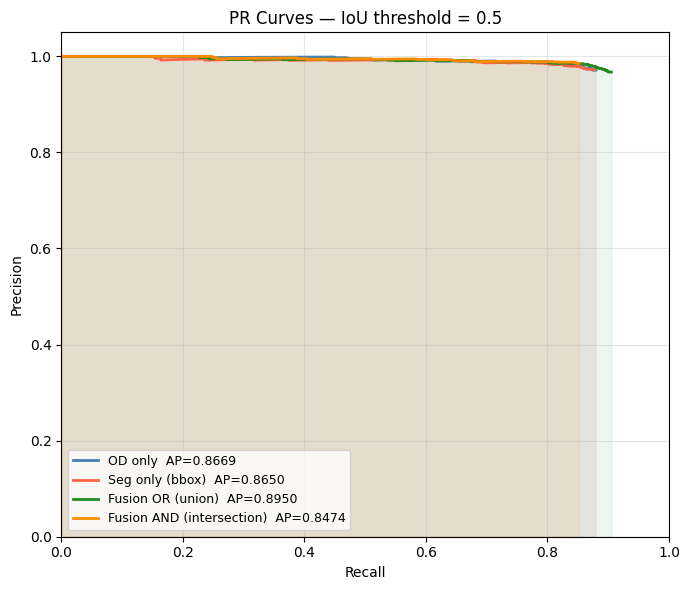

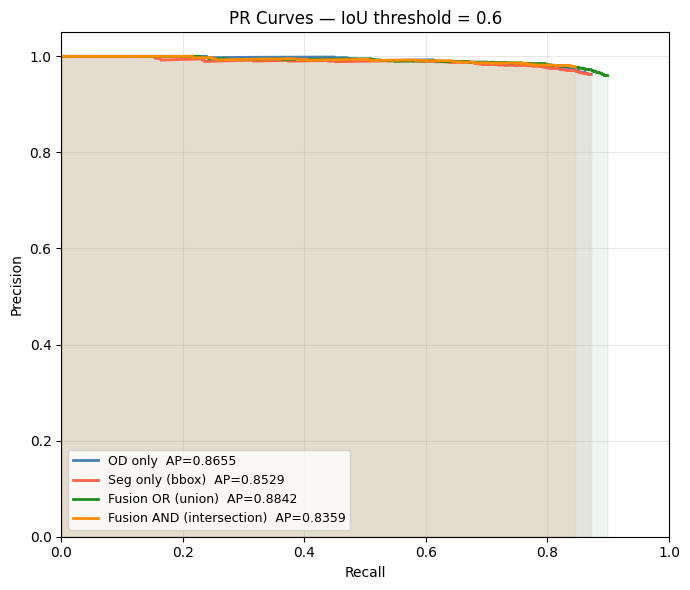

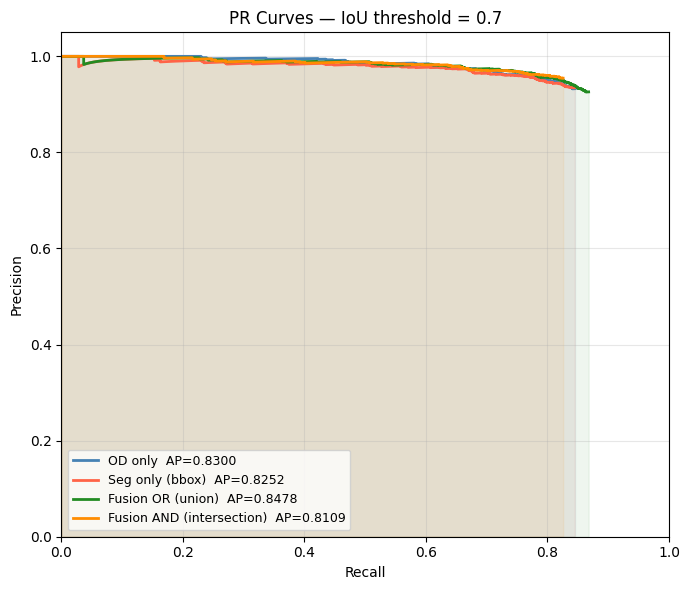

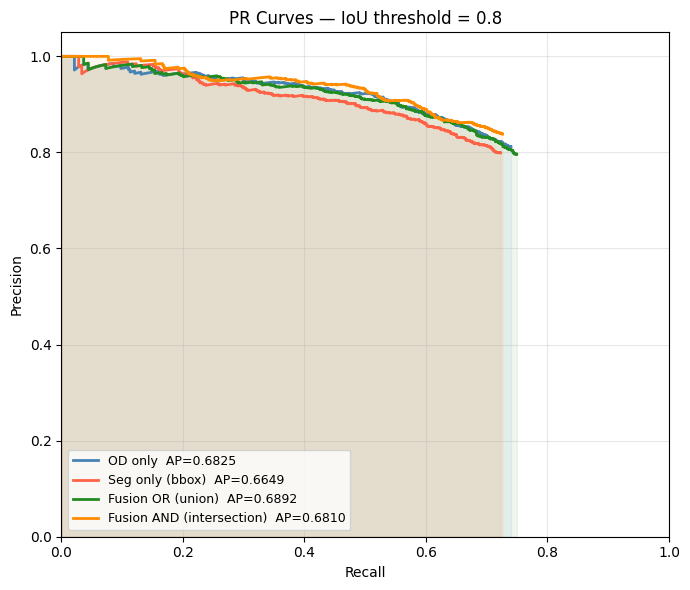

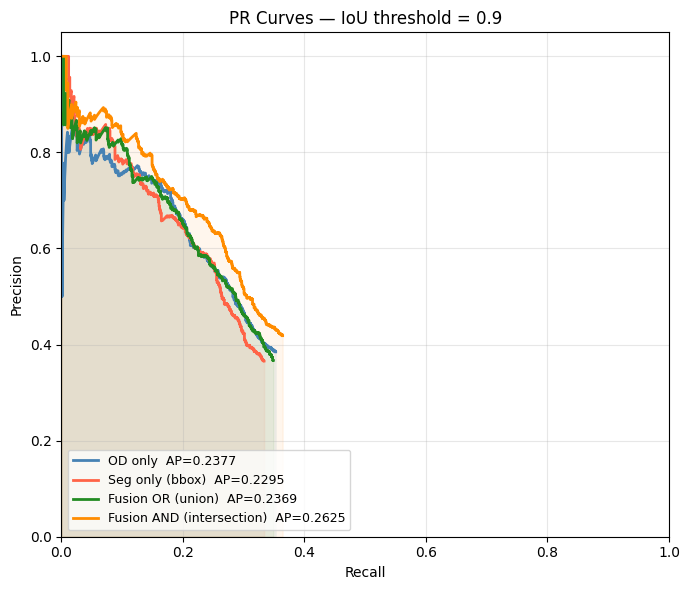

In [234]:
colors = {'od_only': 'steelblue', 'seg_only': 'tomato',
          'or': 'forestgreen', 'and': 'darkorange'}

for iou_threshold in iou_thresholds_report:
    fig, ax = plt.subplots(figsize=(7, 6))
    for strategy in strategies:
        ndf = results_by_strategy_iou[strategy][iou_threshold]
        ap, recalls, precisions = calculate_ap(ndf)
        if len(recalls) == 0:
            continue
        label = f"{strategy_labels[strategy]}  AP={ap:.4f}"
        ax.plot(recalls, precisions, color=colors[strategy], linewidth=2, label=label)
        ax.fill_between(recalls, precisions, alpha=0.07, color=colors[strategy])

    ax.set_xlabel('Recall')
    ax.set_ylabel('Precision')
    ax.set_title(f'PR Curves — IoU threshold = {iou_threshold}')
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1.05])
    ax.legend(fontsize=9, loc='lower left')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

In [235]:
def visualize_ensemble_samples(od_raw, seg_raw, results_by_strategy_iou,
                                od_root, strategy='or', iou_threshold=0.5,
                                n=16, mode='random', seed=42):
    """
    每張圖並排顯示 OD-only / Seg-only / Fused 結果。
    mode: 'random' | 'fp' | 'fn' | 'worst'
    """
    ndf_fused = results_by_strategy_iou[strategy][iou_threshold]
    grouped   = ndf_fused.groupby('file_name')

    if mode == 'random':
        rng = random.Random(seed)
        file_names = rng.sample(list(grouped.groups.keys()), min(n, len(grouped)))
    else:
        counts = (
            ndf_fused[ndf_fused['match_type'].isin(['FP', 'FN'])]
            .groupby(['file_name', 'match_type']).size().unstack(fill_value=0)
        )
        for col in ['FP', 'FN']:
            if col not in counts:
                counts[col] = 0
        if mode == 'fp':
            file_names = counts['FP'].nlargest(n).index.tolist()
        elif mode == 'fn':
            file_names = counts['FN'].nlargest(n).index.tolist()
        else:
            file_names = (counts['FP'] + counts['FN']).nlargest(n).index.tolist()

    # Build filename -> index map
    fname_to_idx = {Path(p).name: i for i, (p, _, _) in enumerate(od_raw)}

    color_map = {'TP_pred': 'lime', 'TP_gt': 'green',
                 'FP_pred': 'red',  'FN_gt': 'orange'}

    def draw_recs(ax, records):
        for rec in records:
            mt = rec['match_type']
            if mt == 'TP':
                for box, c, ls in [(rec['pred_box'], 'lime', '-'),
                                   (rec['gt_box'],   'green', '--')]:
                    if box:
                        ax.add_patch(mpatches.FancyBboxPatch(
                            (0, 0), 1, 1, visible=False))
                        ax.add_patch(plt.Rectangle(
                            (box[0], box[1]), box[2]-box[0], box[3]-box[1],
                            linewidth=2, edgecolor=c, facecolor='none', linestyle=ls))
                if rec['pred_box']:
                    ax.text(rec['pred_box'][0], rec['pred_box'][1]-4,
                            f"TP iou={rec['iou']:.2f}", color='lime', fontsize=6)
            elif mt == 'FP':
                b = rec['pred_box']
                if b:
                    ax.add_patch(plt.Rectangle(
                        (b[0], b[1]), b[2]-b[0], b[3]-b[1],
                        linewidth=2, edgecolor='red', facecolor='none'))
                    ax.text(b[0], b[1]-4, 'FP', color='red', fontsize=6)
            elif mt == 'FN':
                b = rec['gt_box']
                if b:
                    ax.add_patch(plt.Rectangle(
                        (b[0], b[1]), b[2]-b[0], b[3]-b[1],
                        linewidth=2, edgecolor='orange', facecolor='none', linestyle='--'))
                    ax.text(b[0], b[1]-4, 'FN', color='orange', fontsize=6)

    strategy_cols = ['od_only', 'seg_only', strategy]
    col_titles    = ['OD only', 'Seg only', f'Fusion ({strategy})']
    ncols, nrows  = len(strategy_cols), len(file_names)

    fig, axes = plt.subplots(nrows, ncols, figsize=(6*ncols, 5*nrows))
    if nrows == 1:
        axes = axes[np.newaxis, :]

    for row_i, fname in enumerate(file_names):
        idx = fname_to_idx.get(fname)
        if idx is None:
            continue
        od_path = od_raw[idx][0]
        img = cv2.cvtColor(cv2.imread(od_path), cv2.COLOR_BGR2RGB)

        for col_i, strat in enumerate(strategy_cols):
            ax = axes[row_i, col_i]
            ax.imshow(img)
            recs_df = results_by_strategy_iou[strat][iou_threshold]
            if fname in recs_df['file_name'].values:
                draw_recs(ax, recs_df[recs_df['file_name'] == fname].to_dict('records'))
            tp = (recs_df[recs_df['file_name'] == fname]['match_type'] == 'TP').sum()
            fp = (recs_df[recs_df['file_name'] == fname]['match_type'] == 'FP').sum()
            fn = (recs_df[recs_df['file_name'] == fname]['match_type'] == 'FN').sum()
            ax.set_title(f"{col_titles[col_i]}\n{fname}\nTP={tp} FP={fp} FN={fn}",
                         fontsize=8)
            ax.axis('off')

    legend_elems = [
        mpatches.Patch(edgecolor='lime',   facecolor='none', linestyle='-',  label='TP pred'),
        mpatches.Patch(edgecolor='green',  facecolor='none', linestyle='--', label='TP gt'),
        mpatches.Patch(edgecolor='red',    facecolor='none', linestyle='-',  label='FP'),
        mpatches.Patch(edgecolor='orange', facecolor='none', linestyle='--', label='FN'),
    ]
    fig.legend(handles=legend_elems, loc='lower center', ncol=4, fontsize=10)
    plt.suptitle(f"Ensemble comparison  |  IoU={iou_threshold}  |  mode={mode}", fontsize=13)
    plt.tight_layout()
    plt.show()

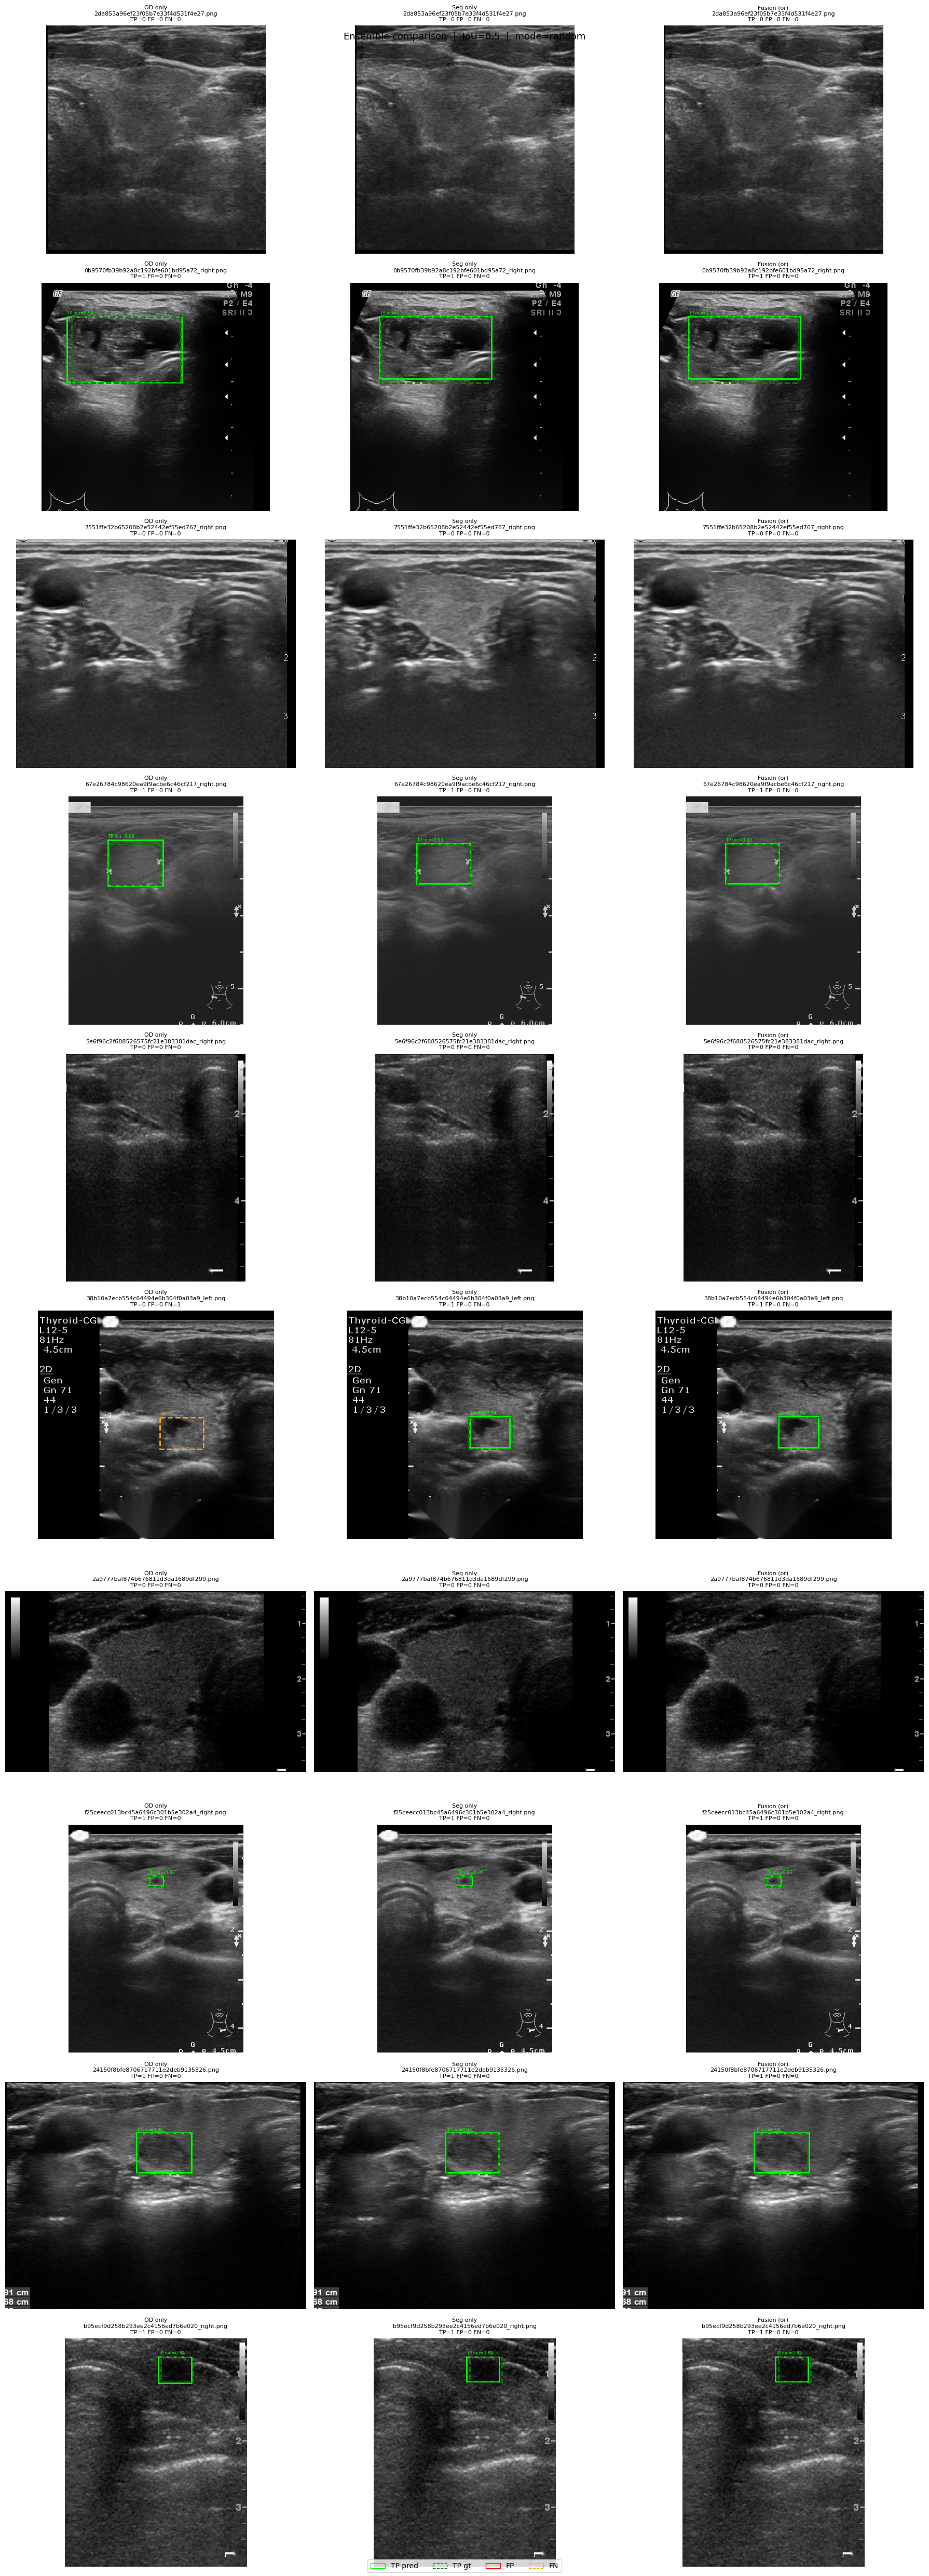

In [236]:
# 調整 mode: 'random' | 'fp' | 'fn' | 'worst'
# 調整 strategy: 'or' | 'and'

visualize_ensemble_samples(
    od_raw, seg_raw, results_by_strategy_iou,
    od_root=od_root,
    strategy='or',
    iou_threshold=0.5,
    n=10,
    mode='random',
)

## 結節大小對效能之影響（定性分析）

以各影像 DICOM 的 Pixel Spacing（`SequenceOfUltrasoundRegions.PhysicalDeltaX/Y`）將 GT bounding box 換算為實際大小（mm），
再以固定切點 **6.9 mm / 12.6 mm** 分為 **小 / 中 / 大** 三類，
分析各策略在不同大小結節上的 Recall、Precision、F1 表現。


In [237]:
# ============================================================
# 載入 DICOM Pixel Spacing，建立 file_name → (ps_x_mm, ps_y_mm) 對應表
# ============================================================
import pydicom, subprocess, re
from pathlib import Path

DCM_ROOT = "/Users/tony.tu/Desktop/戴承智慧/thyroid_old/data/CG_data/all_data"

# 收集所有需要查的 file_name
all_fnames = set()
for strategy in strategies:
    for iou_thr in results_by_strategy_iou[strategy]:
        all_fnames.update(results_by_strategy_iou[strategy][iou_thr]["file_name"].unique())

def fname_to_hash(fname):
    stem = Path(fname).stem  # strip extension first
    return re.sub(r"_(left|right)$", "", stem)

unique_hashes = list({fname_to_hash(f) for f in all_fnames})

# 建立 hash → dcm path 索引
result = subprocess.run(["find", DCM_ROOT, "-name", "*.dcm"], capture_output=True, text=True)
all_dcm = [p for p in result.stdout.strip().split("\n") if p]
hash_to_dcm = {Path(p).stem: p for p in all_dcm}
print(f"DCM 索引: {len(hash_to_dcm)} 個檔案")


DCM 索引: 37187 個檔案


In [238]:

def get_pixel_spacing(dcm_path):
    try:
        print(dcm_path)
        ds = pydicom.dcmread(dcm_path, stop_before_pixels=True)
        if hasattr(ds, "PixelSpacing"):
            ps = ds.PixelSpacing
            return float(ps[1]), float(ps[0])
        if hasattr(ds, "SequenceOfUltrasoundRegions"):
            for reg in ds.SequenceOfUltrasoundRegions:
                pdx = getattr(reg, "PhysicalDeltaX", None)
                pdy = getattr(reg, "PhysicalDeltaY", None)
                if pdx is not None and pdy is not None:
                    return abs(float(pdx)) * 10, abs(float(pdy)) * 10
    except Exception:
        pass
    return None, None

spacing_map = {}
for h in unique_hashes:
    if h in hash_to_dcm:
        spacing_map[h] = get_pixel_spacing(hash_to_dcm[h])
    else:
        spacing_map[h] = (None, None)

found = sum(1 for v in spacing_map.values() if v[0] is not None)
print(f"成功讀取 pixel spacing: {found}/{len(unique_hashes)}")


/Users/tony.tu/Desktop/戴承智慧/thyroid_old/data/CG_data/all_data/1_5_normal/17E313286BBEC55DEAE199148F37739A355928F1/70D9B760151F98AE81B617FFBB5FA2BB42C30DB1/1d9c006dfb8fca03a8fa217894e89fe1.dcm
/Users/tony.tu/Desktop/戴承智慧/thyroid_old/data/CG_data/all_data/1_5_normal/C23F3320B9FC81DBEECC906E862A0E7795928F00/C0C108363356FDF36E05182AF79BB634BE4155E1/a533d5ef7a6b5cbb34b8a28cc21038ff.dcm
/Users/tony.tu/Desktop/戴承智慧/thyroid_old/data/CG_data/all_data/1_5_normal/0CBB30C9BD4F8E545DF1A133306AA9F05F5CB078/EF0A7A3313FFC79D4974C5FC0BB1AB2B096F98CD/03b27eb996353b213223081c628c4197.dcm
/Users/tony.tu/Desktop/戴承智慧/thyroid_old/data/CG_data/all_data/12_26_data_normal/CFBFB06CC9124F7E98F0101773CF0A7993B0FEF2/BCEE218A98E017F1BFE388C4CE9A273320212394/a3fd3ca3aded6e338225f370c446affb.dcm
/Users/tony.tu/Desktop/戴承智慧/thyroid_old/data/CG_data/all_data/12_26_data_for_future/778B9BB6A34025210D000EFB08A4C7F0D7E65645/4A3CEEBCA2B385AA698DA872310AC2E2CC1D7375/410cbb835b2afb55b2caa52069c715af.dcm
/Users/tony.tu/Desktop

In [239]:

# file_name → (ps_x_mm, ps_y_mm)
file_to_spacing = {f: spacing_map[fname_to_hash(f)] for f in all_fnames}

# ── 統計沒有 spacing 資訊的影像數 ──────────────────────────────
no_dcm       = [h for h, v in spacing_map.items() if h not in hash_to_dcm]
dcm_no_space = [h for h, v in spacing_map.items() if h in hash_to_dcm and v[0] is None]
has_space    = [h for h, v in spacing_map.items() if v[0] is not None]

total_imgs       = len(all_fnames)
imgs_no_spacing  = sum(1 for f in all_fnames if file_to_spacing[f][0] is None)
imgs_has_spacing = total_imgs - imgs_no_spacing

print(f"[Pixel Spacing 統計]")
print(f"  總影像數 (file_name):         {total_imgs}")
print(f"  有 spacing 影像數:            {imgs_has_spacing} ({imgs_has_spacing/total_imgs*100:.1f}%)")
print(f"  無 spacing 影像數:            {imgs_no_spacing} ({imgs_no_spacing/total_imgs*100:.1f}%)")
print(f"    ├ 找不到 DCM 檔 (hash):     {len(no_dcm)}")
print(f"    └ DCM 存在但讀不到 spacing: {len(dcm_no_space)}")


# ============================================================
# 結節大小分類設定（固定切點 6.9 / 12.6 mm）
# ============================================================

SIZE_ANALYSIS_IOU = 0.5
Q33_MM = 6.9
Q67_MM = 12.6

SIZE_LABELS = [
    f"Small\n(<{Q33_MM} mm)",
    f"Medium\n({Q33_MM}\u2013{Q67_MM} mm)",
    f"Large\n(\u2265{Q67_MM} mm)",
]

def get_gt_max_dim_mm(box, fname):
    if box is None:
        return None
    ps = file_to_spacing.get(fname, (None, None))
    if ps[0] is None:
        return None
    x1, y1, x2, y2 = box
    w_mm = max(0, x2 - x1) * ps[0]
    h_mm = max(0, y2 - y1) * ps[1]
    return max(w_mm, h_mm)

def size_category(dim_mm):
    if dim_mm is None or (isinstance(dim_mm, float) and np.isnan(dim_mm)):
        return None
    if dim_mm < Q33_MM:
        return SIZE_LABELS[0]
    elif dim_mm < Q67_MM:
        return SIZE_LABELS[1]
    else:
        return SIZE_LABELS[2]

# 統計 OR/IoU=0.5 的 GT 結節 mm 分佈（供直方圖使用）
ref_df = results_by_strategy_iou["or"][SIZE_ANALYSIS_IOU].copy()
ref_gt = ref_df[ref_df["match_type"].isin(["TP", "FN"])].copy()
ref_gt["gt_max_dim_mm"] = ref_gt.apply(
    lambda r: get_gt_max_dim_mm(r["gt_box"], r["file_name"]), axis=1)
ref_dims = ref_gt["gt_max_dim_mm"].dropna()

print(f"\nGT 結節實際大小分佈（Fusion OR, IoU=0.5，有 spacing 資料者）")
print(f"  N        : {len(ref_dims)}")
print(f"  Min      : {ref_dims.min():.2f} mm")
print(f"  Q33 切點  : {Q33_MM} mm  (小/中 分界)")
print(f"  Median   : {ref_dims.median():.2f} mm")
print(f"  Q67 切點  : {Q67_MM} mm  (中/大 分界)")
print(f"  Max      : {ref_dims.max():.2f} mm")


[Pixel Spacing 統計]
  總影像數 (file_name):         2364
  有 spacing 影像數:            2156 (91.2%)
  無 spacing 影像數:            208 (8.8%)
    ├ 找不到 DCM 檔 (hash):     0
    └ DCM 存在但讀不到 spacing: 149

GT 結節實際大小分佈（Fusion OR, IoU=0.5，有 spacing 資料者）
  N        : 1530
  Min      : 2.48 mm
  Q33 切點  : 6.9 mm  (小/中 分界)
  Median   : 9.79 mm
  Q67 切點  : 12.6 mm  (中/大 分界)
  Max      : 51.24 mm


/var/folders/52/nxxlf7js5vv8b4p_73c32whw0000gn/T/ipykernel_84922/3680458613.py:37: UserWarning: Glyph 26368 (\N{CJK UNIFIED IDEOGRAPH-6700}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/52/nxxlf7js5vv8b4p_73c32whw0000gn/T/ipykernel_84922/3680458613.py:37: UserWarning: Glyph 22823 (\N{CJK UNIFIED IDEOGRAPH-5927}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/52/nxxlf7js5vv8b4p_73c32whw0000gn/T/ipykernel_84922/3680458613.py:37: UserWarning: Glyph 37002 (\N{CJK UNIFIED IDEOGRAPH-908A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/52/nxxlf7js5vv8b4p_73c32whw0000gn/T/ipykernel_84922/3680458613.py:37: UserWarning: Glyph 38263 (\N{CJK UNIFIED IDEOGRAPH-9577}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/52/nxxlf7js5vv8b4p_73c32whw0000gn/T/ipykernel_84922/3680458613.py:37: UserWarning: Glyph 32080 (\N{CJK UNIFIED IDEOGRAPH-7D50}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/52/nxxl

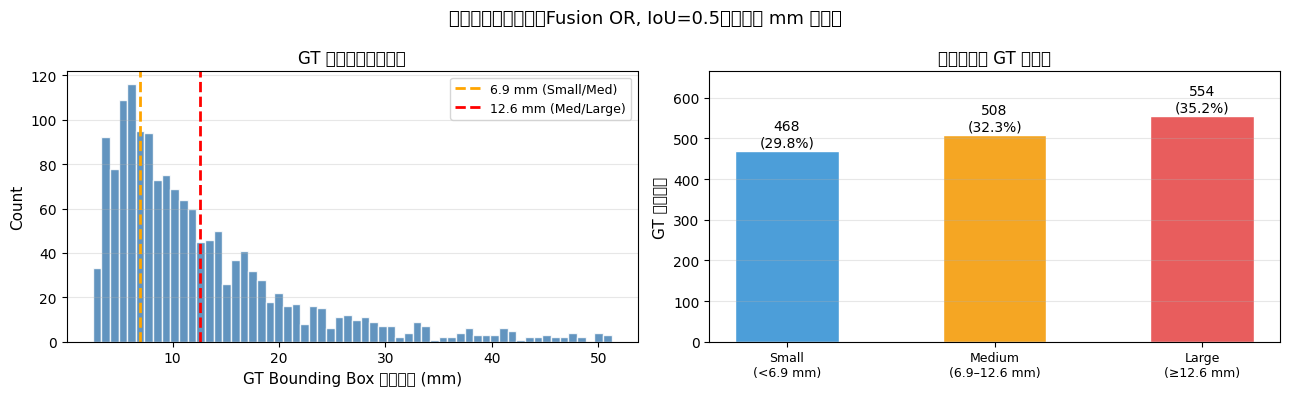

In [240]:
# ============================================================
# 結節大小（mm）分佈直方圖 + 大小分組佔比
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# 左：mm 直方圖
ax = axes[0]
ax.hist(ref_dims, bins=60, color="steelblue", edgecolor="white", alpha=0.85)
ax.axvline(Q33_MM, color="orange", linewidth=2, linestyle="--", label=f"6.9 mm (Small/Med)")
ax.axvline(Q67_MM, color="red",    linewidth=2, linestyle="--", label=f"12.6 mm (Med/Large)")
ax.set_xlabel("GT Bounding Box 最大邊長 (mm)", fontsize=11)
ax.set_ylabel("Count", fontsize=11)
ax.set_title("GT 結節實際大小分佈", fontsize=12)
ax.legend(fontsize=9)
ax.grid(axis="y", alpha=0.3)

# 右：各大小分組 GT 數量
ref_gt["size_cat"] = ref_gt["gt_max_dim_mm"].apply(size_category)
cat_counts = ref_gt["size_cat"].value_counts().reindex(SIZE_LABELS).fillna(0)

ax2 = axes[1]
bars = ax2.bar(range(len(SIZE_LABELS)), cat_counts.values,
               color=["#4C9ED9", "#F5A623", "#E85D5D"], edgecolor="white", width=0.5)
for bar, val in zip(bars, cat_counts.values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             f"{int(val)}\n({int(val)/len(ref_gt)*100:.1f}%)",
             ha="center", va="bottom", fontsize=10)
ax2.set_xticks(range(len(SIZE_LABELS)))
ax2.set_xticklabels(SIZE_LABELS, fontsize=9)
ax2.set_ylabel("GT 結節數量", fontsize=11)
ax2.set_title("各大小分組 GT 結節數", fontsize=12)
ax2.grid(axis="y", alpha=0.3)
ax2.set_ylim(0, cat_counts.max() * 1.2)

plt.suptitle("結節大小分佈概覽（Fusion OR, IoU=0.5，以實際 mm 分類）", fontsize=13)
plt.tight_layout()
plt.show()


In [241]:
# ============================================================
# 各策略 × 結節大小（mm）→ TP/FP/FN 計數 & 指標
# ============================================================

size_records = []

for strategy in strategies:
    df = results_by_strategy_iou[strategy][SIZE_ANALYSIS_IOU].copy()

    # TP / FN → GT box mm；FP → pred box mm
    df["gt_max_dim_mm"] = df.apply(
        lambda r: get_gt_max_dim_mm(r["gt_box"], r["file_name"]), axis=1)
    fp_mask = df["match_type"] == "FP"
    df.loc[fp_mask, "gt_max_dim_mm"] = df.loc[fp_mask].apply(
        lambda r: get_gt_max_dim_mm(r["pred_box"], r["file_name"]), axis=1)

    df["size_cat"] = df["gt_max_dim_mm"].apply(size_category)
    df = df.dropna(subset=["size_cat"])

    for sc in SIZE_LABELS:
        sub = df[df["size_cat"] == sc]
        tp = (sub["match_type"] == "TP").sum()
        fp = (sub["match_type"] == "FP").sum()
        fn = (sub["match_type"] == "FN").sum()
        recall, precision, f1 = compute_metrics_from_counts(tp, fp, fn)
        tp_iou = sub.loc[sub["match_type"] == "TP", "iou"].dropna()
        size_records.append({
            "strategy":  strategy,
            "label":     strategy_labels[strategy],
            "size_cat":  sc,
            "TP": tp, "FP": fp, "FN": fn,
            "recall":    recall,
            "precision": precision,
            "f1":        f1,
            "mean_iou":  tp_iou.mean() if len(tp_iou) else np.nan,
        })

size_df = pd.DataFrame(size_records)

pivot_f1     = size_df.pivot_table(index="label", columns="size_cat", values="f1",        aggfunc="first")[SIZE_LABELS]
pivot_recall = size_df.pivot_table(index="label", columns="size_cat", values="recall",    aggfunc="first")[SIZE_LABELS]
pivot_prec   = size_df.pivot_table(index="label", columns="size_cat", values="precision", aggfunc="first")[SIZE_LABELS]

print("=== F1 by Nodule Size (IoU=0.5, mm-based) ===")
display(pivot_f1.round(4))
print("\n=== Recall by Nodule Size ===")
display(pivot_recall.round(4))
print("\n=== Precision by Nodule Size ===")
display(pivot_prec.round(4))


=== F1 by Nodule Size (IoU=0.5, mm-based) ===


size_cat,Small\n(<6.9 mm),Medium\n(6.9–12.6 mm),Large\n(≥12.6 mm)
label,,,
Fusion AND (intersection),0.8946,0.9146,0.9235
Fusion OR (union),0.9272,0.9298,0.9446
OD only,0.9033,0.9269,0.9323
Seg only (bbox),0.9110,0.9180,0.9336



=== Recall by Nodule Size ===


size_cat,Small\n(<6.9 mm),Medium\n(6.9–12.6 mm),Large\n(≥12.6 mm)
label,,,
Fusion AND (intersection),0.8162,0.8543,0.8718
Fusion OR (union),0.8846,0.8996,0.9242
OD only,0.8483,0.8858,0.8953
Seg only (bbox),0.8526,0.8701,0.9007



=== Precision by Nodule Size ===


size_cat,Small\n(<6.9 mm),Medium\n(6.9–12.6 mm),Large\n(≥12.6 mm)
label,,,
Fusion AND (intersection),0.9896,0.9841,0.9817
Fusion OR (union),0.9741,0.9621,0.9660
OD only,0.9659,0.9719,0.9725
Seg only (bbox),0.9779,0.9714,0.9689


/var/folders/52/nxxlf7js5vv8b4p_73c32whw0000gn/T/ipykernel_84922/2930694873.py:37: UserWarning: Glyph 32080 (\N{CJK UNIFIED IDEOGRAPH-7D50}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/52/nxxlf7js5vv8b4p_73c32whw0000gn/T/ipykernel_84922/2930694873.py:37: UserWarning: Glyph 31680 (\N{CJK UNIFIED IDEOGRAPH-7BC0}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/52/nxxlf7js5vv8b4p_73c32whw0000gn/T/ipykernel_84922/2930694873.py:37: UserWarning: Glyph 22823 (\N{CJK UNIFIED IDEOGRAPH-5927}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/52/nxxlf7js5vv8b4p_73c32whw0000gn/T/ipykernel_84922/2930694873.py:37: UserWarning: Glyph 23567 (\N{CJK UNIFIED IDEOGRAPH-5C0F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/52/nxxlf7js5vv8b4p_73c32whw0000gn/T/ipykernel_84922/2930694873.py:37: UserWarning: Glyph 23565 (\N{CJK UNIFIED IDEOGRAPH-5C0D}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/52/nxxl

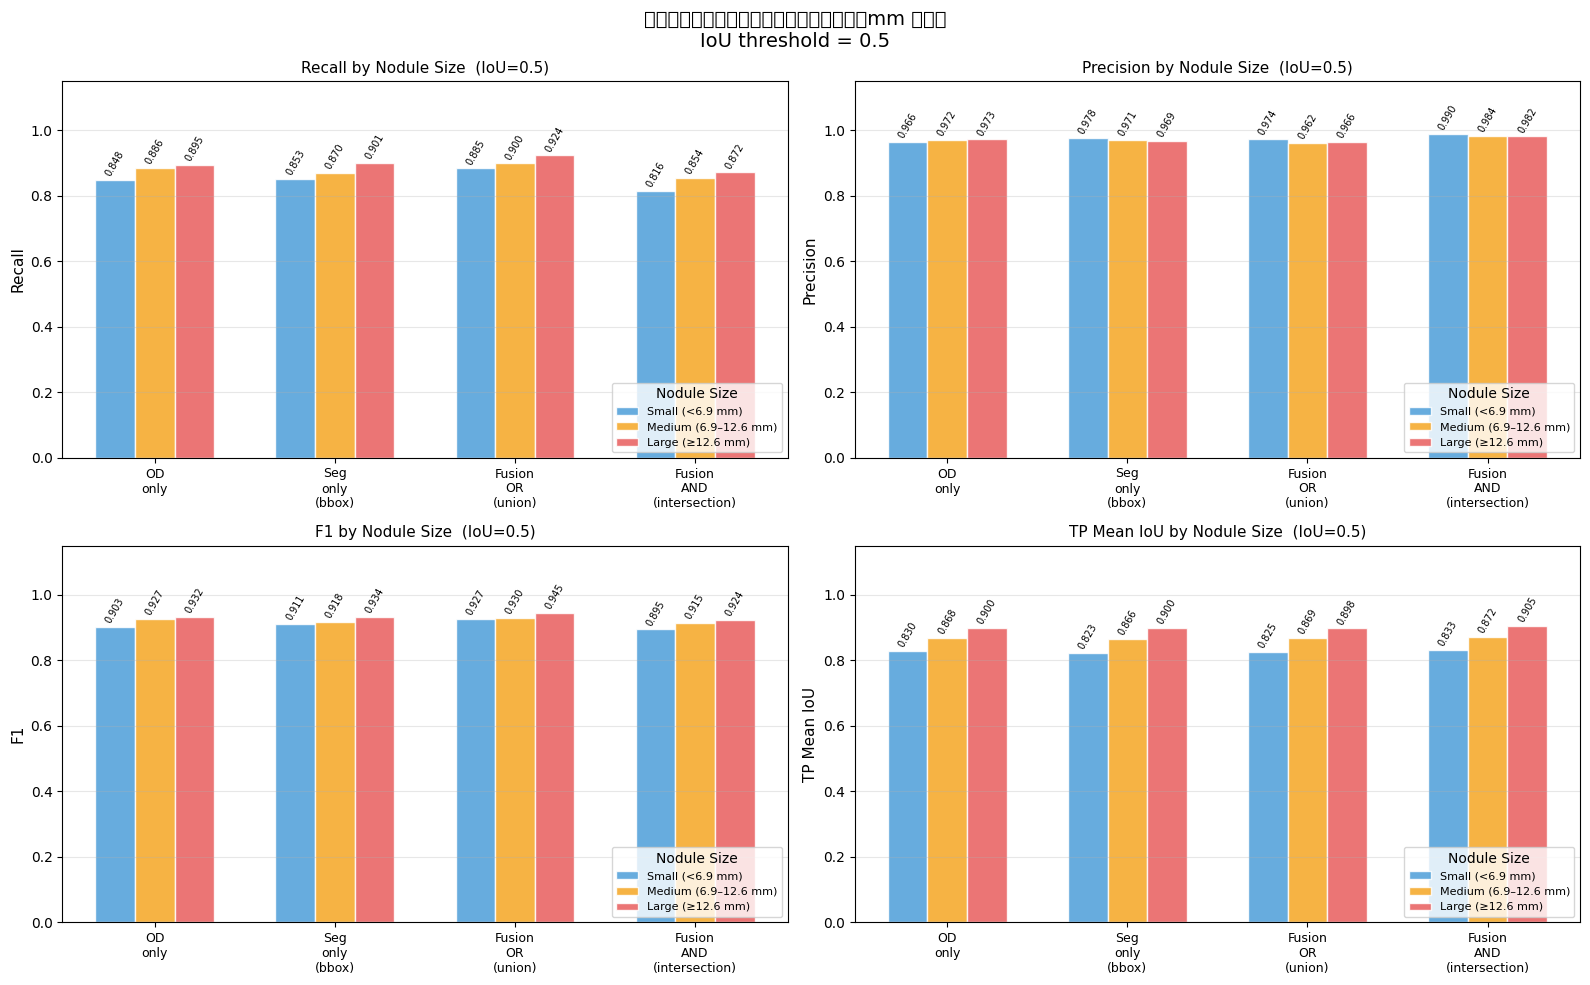

In [242]:
# ============================================================
# 視覺化：各策略 × 大小分組 的 Recall / Precision / F1 / TP-IoU
# ============================================================

metrics_to_plot = ['recall', 'precision', 'f1', 'mean_iou']
metric_titles   = ['Recall', 'Precision', 'F1', 'TP Mean IoU']
size_colors     = ['#4C9ED9', '#F5A623', '#E85D5D']   # small / medium / large

x      = np.arange(len(strategies))
width  = 0.22

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for ax, metric, title in zip(axes.flat, metrics_to_plot, metric_titles):
    for si, sc in enumerate(SIZE_LABELS):
        vals = []
        for strategy in strategies:
            row = size_df[(size_df['strategy'] == strategy) & (size_df['size_cat'] == sc)]
            vals.append(float(row[metric].values[0]) if len(row) > 0 else 0)
        offset = (si - 1) * width
        bars = ax.bar(x + offset, vals, width, label=sc.replace('\n', ' '),
                      color=size_colors[si], alpha=0.85, edgecolor='white')
        for bar, v in zip(bars, vals):
            if not np.isnan(v):
                ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                        f'{v:.3f}', ha='center', va='bottom', fontsize=7, rotation=60)

    ax.set_xticks(x)
    ax.set_xticklabels([strategy_labels[s].replace(' ', '\n') for s in strategies], fontsize=9)
    ax.set_ylim(0, 1.15)
    ax.set_ylabel(title, fontsize=11)
    ax.set_title(f'{title} by Nodule Size  (IoU={SIZE_ANALYSIS_IOU})', fontsize=11)
    ax.legend(title='Nodule Size', fontsize=8, loc='lower right')
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('結節大小對各策略效能之影響（定性分析，mm 分類）\nIoU threshold = 0.5', fontsize=14)
plt.tight_layout()
plt.show()

/var/folders/52/nxxlf7js5vv8b4p_73c32whw0000gn/T/ipykernel_84922/1915546100.py:38: UserWarning: Glyph 21508 (\N{CJK UNIFIED IDEOGRAPH-5404}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/52/nxxlf7js5vv8b4p_73c32whw0000gn/T/ipykernel_84922/1915546100.py:38: UserWarning: Glyph 32080 (\N{CJK UNIFIED IDEOGRAPH-7D50}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/52/nxxlf7js5vv8b4p_73c32whw0000gn/T/ipykernel_84922/1915546100.py:38: UserWarning: Glyph 31680 (\N{CJK UNIFIED IDEOGRAPH-7BC0}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/52/nxxlf7js5vv8b4p_73c32whw0000gn/T/ipykernel_84922/1915546100.py:38: UserWarning: Glyph 22823 (\N{CJK UNIFIED IDEOGRAPH-5927}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/52/nxxlf7js5vv8b4p_73c32whw0000gn/T/ipykernel_84922/1915546100.py:38: UserWarning: Glyph 23567 (\N{CJK UNIFIED IDEOGRAPH-5C0F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/52/nxxl

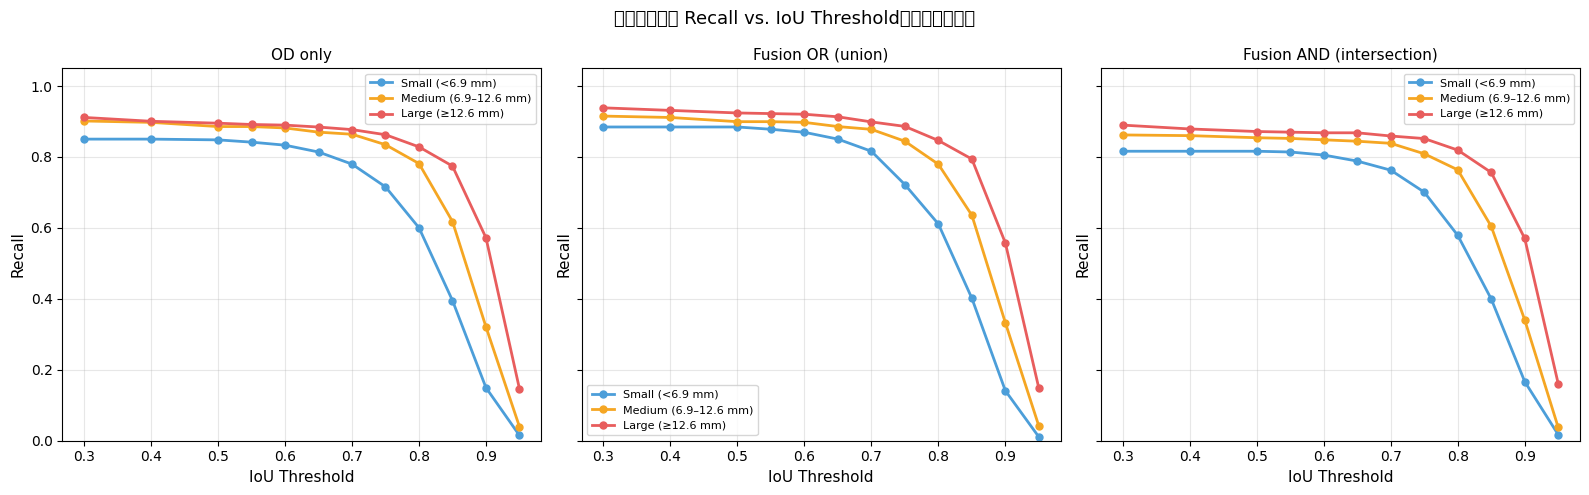

In [243]:
# ============================================================
# 跨 IoU 閾值分析：各大小類別的 Recall 趨勢（以 OR 策略為例）
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
iou_sweep = iou_thresholds_report   # [0.3, 0.5, 0.7]

# 改用連續的 IoU 值呈現趨勢
iou_sweep_full = all_iou_thresholds   # 全部評估過的閾值

for ax, strategy in zip(axes, ['od_only', 'or', 'and']):
    for si, sc in enumerate(SIZE_LABELS):
        recalls = []
        for iou_thr_val in iou_sweep_full:
            df_iou = results_by_strategy_iou[strategy][iou_thr_val].copy()
            df_iou['gt_max_dim_mm'] = df_iou.apply(
                lambda r: get_gt_max_dim_mm(r['gt_box'], r['file_name']), axis=1)
            fp_m = df_iou['match_type'] == 'FP'
            df_iou.loc[fp_m, 'gt_max_dim_mm'] = df_iou.loc[fp_m].apply(
                lambda r: get_gt_max_dim_mm(r['pred_box'], r['file_name']), axis=1)
            df_iou['size_cat'] = df_iou['gt_max_dim_mm'].apply(size_category)
            sub = df_iou[df_iou['size_cat'] == sc]
            tp = (sub['match_type'] == 'TP').sum()
            fn = (sub['match_type'] == 'FN').sum()
            recall, _, _ = compute_metrics_from_counts(tp, 0, fn)
            recalls.append(recall)
        ax.plot(iou_sweep_full, recalls, marker='o', markersize=5,
                color=size_colors[si], linewidth=2,
                label=sc.replace('\n', ' '))
    ax.set_xlabel('IoU Threshold', fontsize=11)
    ax.set_ylabel('Recall', fontsize=11)
    ax.set_title(f'{strategy_labels[strategy]}', fontsize=11)
    ax.set_ylim(0, 1.05)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.suptitle('各結節大小的 Recall vs. IoU Threshold（跨策略比較）', fontsize=13)
plt.tight_layout()
plt.show()

/var/folders/52/nxxlf7js5vv8b4p_73c32whw0000gn/T/ipykernel_84922/1068648957.py:89: UserWarning: Glyph 32080 (\N{CJK UNIFIED IDEOGRAPH-7D50}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/52/nxxlf7js5vv8b4p_73c32whw0000gn/T/ipykernel_84922/1068648957.py:89: UserWarning: Glyph 31680 (\N{CJK UNIFIED IDEOGRAPH-7BC0}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/52/nxxlf7js5vv8b4p_73c32whw0000gn/T/ipykernel_84922/1068648957.py:89: UserWarning: Glyph 22823 (\N{CJK UNIFIED IDEOGRAPH-5927}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/52/nxxlf7js5vv8b4p_73c32whw0000gn/T/ipykernel_84922/1068648957.py:89: UserWarning: Glyph 23567 (\N{CJK UNIFIED IDEOGRAPH-5C0F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/52/nxxlf7js5vv8b4p_73c32whw0000gn/T/ipykernel_84922/1068648957.py:89: UserWarning: Glyph 27171 (\N{CJK UNIFIED IDEOGRAPH-6A23}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/52/nxxl

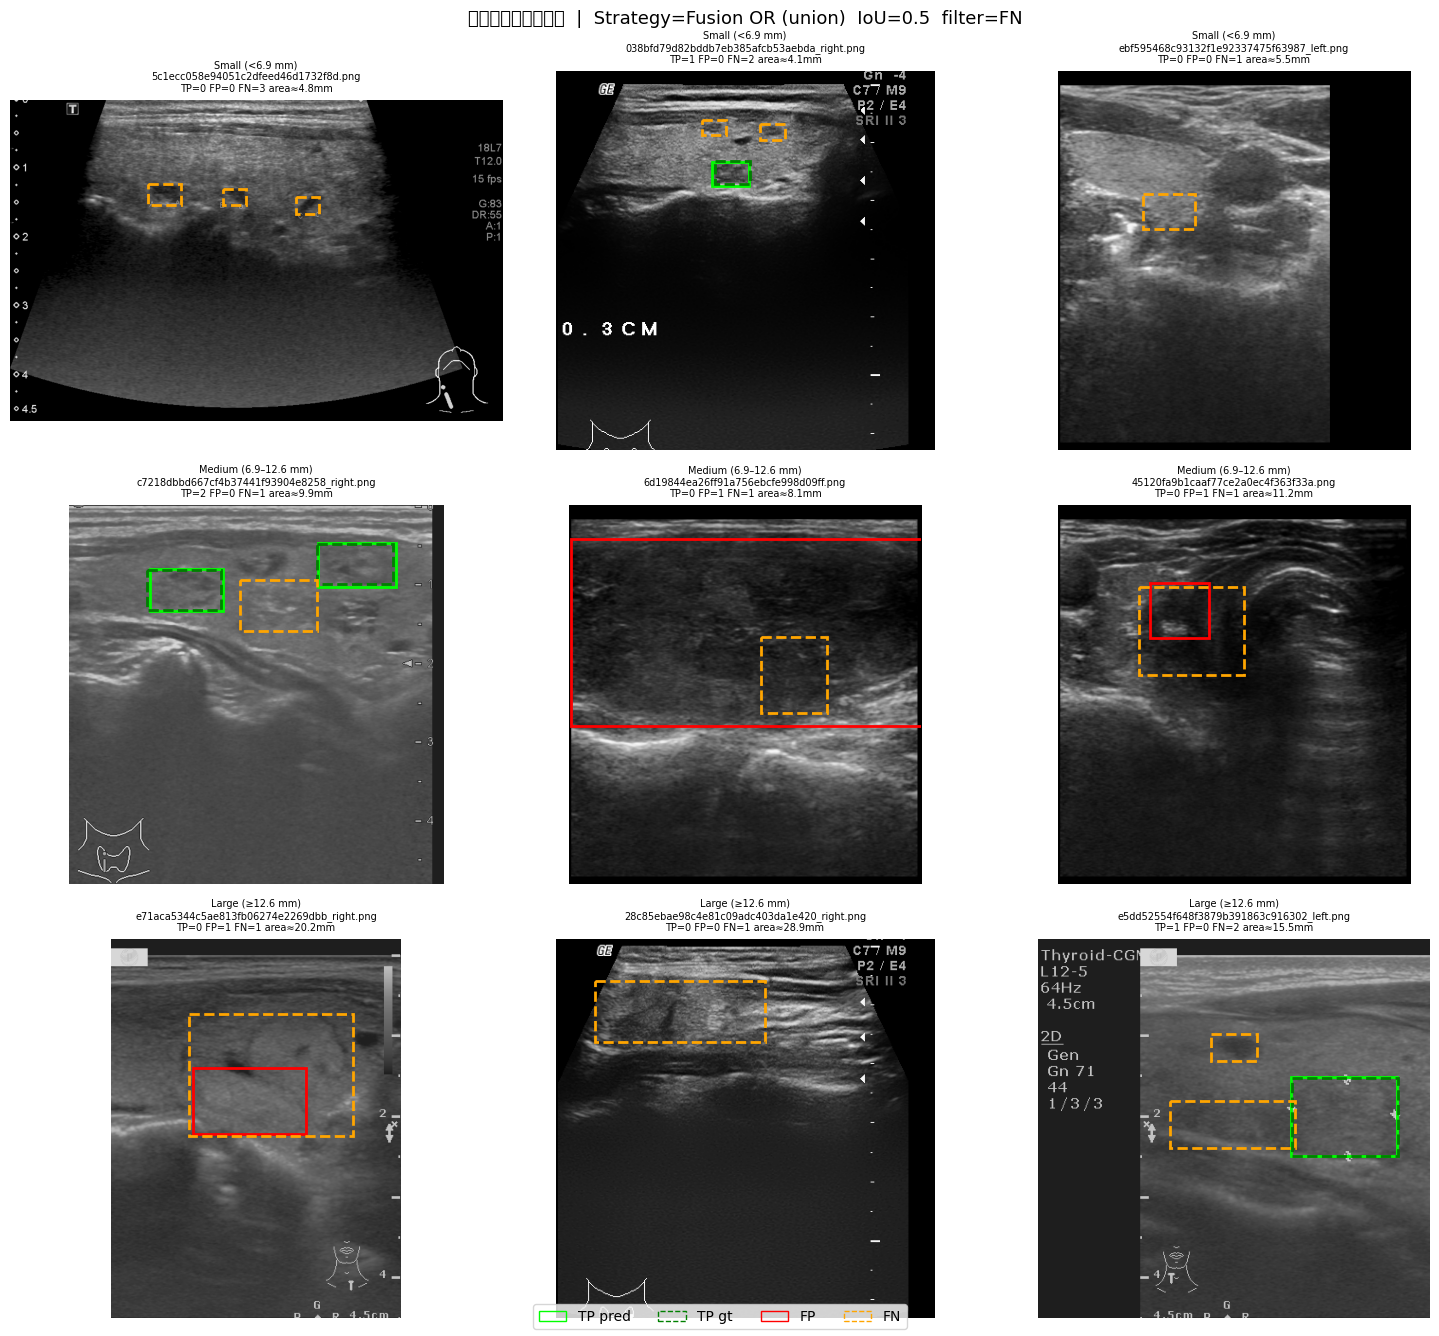

In [244]:
# ============================================================
# 樣本視覺化：每個大小分組各取 N 個 FN（漏偵）和 TP 案例
# ============================================================

def visualize_by_size(od_raw, seg_raw, results_by_strategy_iou,
                      strategy='or', iou_threshold=0.5,
                      n_per_cat=3, match_type_filter='FN', seed=42):
    """
    按結節大小分組，從指定 match_type（FN 或 TP）中各抽樣 n_per_cat 張圖顯示。
    """
    rng = random.Random(seed)
    df = results_by_strategy_iou[strategy][iou_threshold].copy()
    df['gt_max_dim_mm'] = df.apply(
        lambda r: get_gt_max_dim_mm(r['gt_box'], r['file_name']), axis=1)
    fp_m = df['match_type'] == 'FP'
    df.loc[fp_m, 'gt_max_dim_mm'] = df.loc[fp_m].apply(
        lambda r: get_gt_max_dim_mm(r['pred_box'], r['file_name']), axis=1)
    df['size_cat'] = df['gt_max_dim_mm'].apply(size_category)

    fname_to_idx = {Path(p).name: i for i, (p, _, _) in enumerate(od_raw)}

    nrows = len(SIZE_LABELS)
    ncols = n_per_cat
    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4.5 * nrows))
    if nrows == 1:
        axes = axes[np.newaxis, :]

    for row_i, sc in enumerate(SIZE_LABELS):
        sub = df[(df['size_cat'] == sc) & (df['match_type'] == match_type_filter)]
        fnames = sub['file_name'].unique().tolist()
        fnames = rng.sample(fnames, min(n_per_cat, len(fnames)))

        for col_i in range(ncols):
            ax = axes[row_i, col_i]
            ax.axis('off')
            if col_i >= len(fnames):
                continue
            fname = fnames[col_i]
            idx = fname_to_idx.get(fname)
            if idx is None:
                continue
            od_path = od_raw[idx][0]
            img = cv2.cvtColor(cv2.imread(od_path), cv2.COLOR_BGR2RGB)
            ax.imshow(img)

            recs = df[df['file_name'] == fname].to_dict('records')
            for rec in recs:
                mt = rec['match_type']
                if mt == 'TP':
                    for box, c, ls in [(rec['pred_box'], 'lime', '-'),
                                       (rec['gt_box'],   'green', '--')]:
                        if box:
                            ax.add_patch(plt.Rectangle(
                                (box[0], box[1]), box[2]-box[0], box[3]-box[1],
                                linewidth=2, edgecolor=c, facecolor='none', linestyle=ls))
                elif mt == 'FP':
                    b = rec['pred_box']
                    if b:
                        ax.add_patch(plt.Rectangle(
                            (b[0], b[1]), b[2]-b[0], b[3]-b[1],
                            linewidth=2, edgecolor='red', facecolor='none'))
                elif mt == 'FN':
                    b = rec['gt_box']
                    if b:
                        ax.add_patch(plt.Rectangle(
                            (b[0], b[1]), b[2]-b[0], b[3]-b[1],
                            linewidth=2, edgecolor='orange', facecolor='none', linestyle='--'))

            tp = sum(1 for r in recs if r['match_type'] == 'TP')
            fp = sum(1 for r in recs if r['match_type'] == 'FP')
            fn = sum(1 for r in recs if r['match_type'] == 'FN')
            dim_val = sub[sub['file_name'] == fname]['gt_max_dim_mm'].values
            area_str = f"{dim_val[0]:.1f}mm" if len(dim_val) > 0 else ''
            ax.set_title(f"{sc.replace(chr(10), ' ')}\n{fname}\nTP={tp} FP={fp} FN={fn} area≈{area_str}",
                         fontsize=7)

    legend_elems = [
        mpatches.Patch(edgecolor='lime',   facecolor='none', linestyle='-',  label='TP pred'),
        mpatches.Patch(edgecolor='green',  facecolor='none', linestyle='--', label='TP gt'),
        mpatches.Patch(edgecolor='red',    facecolor='none', linestyle='-',  label='FP'),
        mpatches.Patch(edgecolor='orange', facecolor='none', linestyle='--', label='FN'),
    ]
    fig.legend(handles=legend_elems, loc='lower center', ncol=4, fontsize=10)
    plt.suptitle(
        f'結節大小樣本視覺化  |  Strategy={strategy_labels[strategy]}  '
        f'IoU={iou_threshold}  filter={match_type_filter}',
        fontsize=13
    )
    plt.tight_layout()
    plt.show()

# FN（漏偵）樣本：最能體現小結節偵測困難
visualize_by_size(od_raw, seg_raw, results_by_strategy_iou,
                  strategy='or', iou_threshold=0.5,
                  n_per_cat=3, match_type_filter='FN')

## 結節數量對效能之影響

以每張影像的 GT 結節數（1, 2, 3, … 顆）分組，分析各策略的 Recall、Precision、F1 表現。

In [245]:
# ============================================================
# 每張影像 GT 結節數 → 效能分析
# ============================================================

NODULE_COUNT_IOU = 0.5   # 分析用的 IoU 閾值
MAX_NODULE_SHOW  = 7     # 超過此數量的影像合併為 "≥N"

def get_gt_nodule_count_per_image(df):
    """計算每張影像的 GT 結節數（TP + FN）。"""
    counts = (
        df[df['match_type'].isin(['TP', 'FN'])]
        .groupby('file_name').size()
    )
    # TN（無 GT、無預測）的影像設為 0，排除已在 counts 中的 file_name
    tn_files = df[df['match_type'] == 'TN']['file_name'].unique()
    tn_files = [f for f in tn_files if f not in counts.index]
    tn_series = pd.Series(0, index=tn_files)
    return pd.concat([counts, tn_series])


# 以 OR 策略建立 file_name → GT 結節數 的對應表（所有策略共用同一 GT）
ref_df_cnt = results_by_strategy_iou['or'][NODULE_COUNT_IOU]
gt_count_map = get_gt_nodule_count_per_image(ref_df_cnt)

# 結節數分佈
count_dist = gt_count_map.value_counts().sort_index()
print("每張影像 GT 結節數分佈：")
print(count_dist.to_string())
print(f"\nTotal images: {len(gt_count_map)}")

每張影像 GT 結節數分佈：
0     920
1    1327
2     102
3      14

Total images: 2363


In [246]:
# ============================================================
# 各策略 × 結節數量 → TP/FP/FN 計數 & 指標
# ============================================================

def nodule_count_label(n, max_show=MAX_NODULE_SHOW):
    if n >= max_show:
        return f'≥{max_show}'
    return str(int(n))

nodule_count_records = []

for strategy in strategies:
    df = results_by_strategy_iou[strategy][NODULE_COUNT_IOU].copy()
    df['gt_nodule_count'] = df['file_name'].map(gt_count_map)

    for cnt_val, grp in df.groupby('gt_nodule_count'):
        label = nodule_count_label(cnt_val)
        tp = (grp['match_type'] == 'TP').sum()
        fp = (grp['match_type'] == 'FP').sum()
        fn = (grp['match_type'] == 'FN').sum()
        n_images = grp['file_name'].nunique()
        recall, precision, f1 = compute_metrics_from_counts(tp, fp, fn)
        tp_iou = grp.loc[grp['match_type'] == 'TP', 'iou'].dropna()
        nodule_count_records.append({
            'strategy':      strategy,
            'label':         strategy_labels[strategy],
            'nodule_count':  cnt_val,
            'count_label':   label,
            'n_images':      n_images,
            'TP': tp, 'FP': fp, 'FN': fn,
            'recall':        recall,
            'precision':     precision,
            'f1':            f1,
            'mean_iou':      tp_iou.mean() if len(tp_iou) else np.nan,
        })

cnt_df = pd.DataFrame(nodule_count_records)

# ---- 建立顯示用的 label 順序（1,2,3,...,≥N）
raw_counts = sorted(cnt_df['nodule_count'].unique())
label_order = [nodule_count_label(c) for c in raw_counts]
label_order = list(dict.fromkeys(label_order))   # 去重且保序

# ---- 樞紐表：F1
pivot_f1_cnt = cnt_df.pivot_table(
    index='label', columns='count_label', values='f1', aggfunc='first'
).reindex(columns=label_order)
pivot_recall_cnt = cnt_df.pivot_table(
    index='label', columns='count_label', values='recall', aggfunc='first'
).reindex(columns=label_order)
pivot_prec_cnt = cnt_df.pivot_table(
    index='label', columns='count_label', values='precision', aggfunc='first'
).reindex(columns=label_order)

print(f"=== F1 by Nodule Count per Image (IoU={NODULE_COUNT_IOU}) ===")
display(pivot_f1_cnt.round(4))
print(f"\n=== Recall by Nodule Count ===")
display(pivot_recall_cnt.round(4))
print(f"\n=== Precision by Nodule Count ===")
display(pivot_prec_cnt.round(4))

# 影像數量分佈（只印一次）
n_img_per_cnt = cnt_df[cnt_df['strategy'] == 'or'][['count_label', 'n_images']].set_index('count_label').reindex(label_order)
print(f"\n影像數量 per 結節數：")
display(n_img_per_cnt.T)

=== F1 by Nodule Count per Image (IoU=0.5) ===


count_label,0,1,2,3
label,,,,
Fusion AND (intersection),0.0,0.9504,0.6901,0.4912
Fusion OR (union),0.0,0.9656,0.7683,0.5667
OD only,0.0,0.9567,0.7327,0.5172
Seg only (bbox),0.0,0.9575,0.7160,0.5424



=== Recall by Nodule Count ===


count_label,0,1,2,3
label,,,,
Fusion AND (intersection),0.0,0.9179,0.5294,0.3333
Fusion OR (union),0.0,0.9616,0.6422,0.4048
OD only,0.0,0.9397,0.5980,0.3571
Seg only (bbox),0.0,0.9412,0.5686,0.3810



=== Precision by Nodule Count ===


count_label,0,1,2,3
label,,,,
Fusion AND (intersection),0.0,0.9854,0.9908,0.9333
Fusion OR (union),0.0,0.9696,0.9562,0.9444
OD only,0.0,0.9742,0.9457,0.9375
Seg only (bbox),0.0,0.9743,0.9667,0.9412



影像數量 per 結節數：


count_label,0,1,2,3
n_images,920,1327,102,14


/var/folders/52/nxxlf7js5vv8b4p_73c32whw0000gn/T/ipykernel_84922/2383944247.py:39: UserWarning: Glyph 32080 (\N{CJK UNIFIED IDEOGRAPH-7D50}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/52/nxxlf7js5vv8b4p_73c32whw0000gn/T/ipykernel_84922/2383944247.py:39: UserWarning: Glyph 31680 (\N{CJK UNIFIED IDEOGRAPH-7BC0}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/52/nxxlf7js5vv8b4p_73c32whw0000gn/T/ipykernel_84922/2383944247.py:39: UserWarning: Glyph 25976 (\N{CJK UNIFIED IDEOGRAPH-6578}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/52/nxxlf7js5vv8b4p_73c32whw0000gn/T/ipykernel_84922/2383944247.py:39: UserWarning: Glyph 24433 (\N{CJK UNIFIED IDEOGRAPH-5F71}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/52/nxxlf7js5vv8b4p_73c32whw0000gn/T/ipykernel_84922/2383944247.py:39: UserWarning: Glyph 20687 (\N{CJK UNIFIED IDEOGRAPH-50CF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/52/nxxl

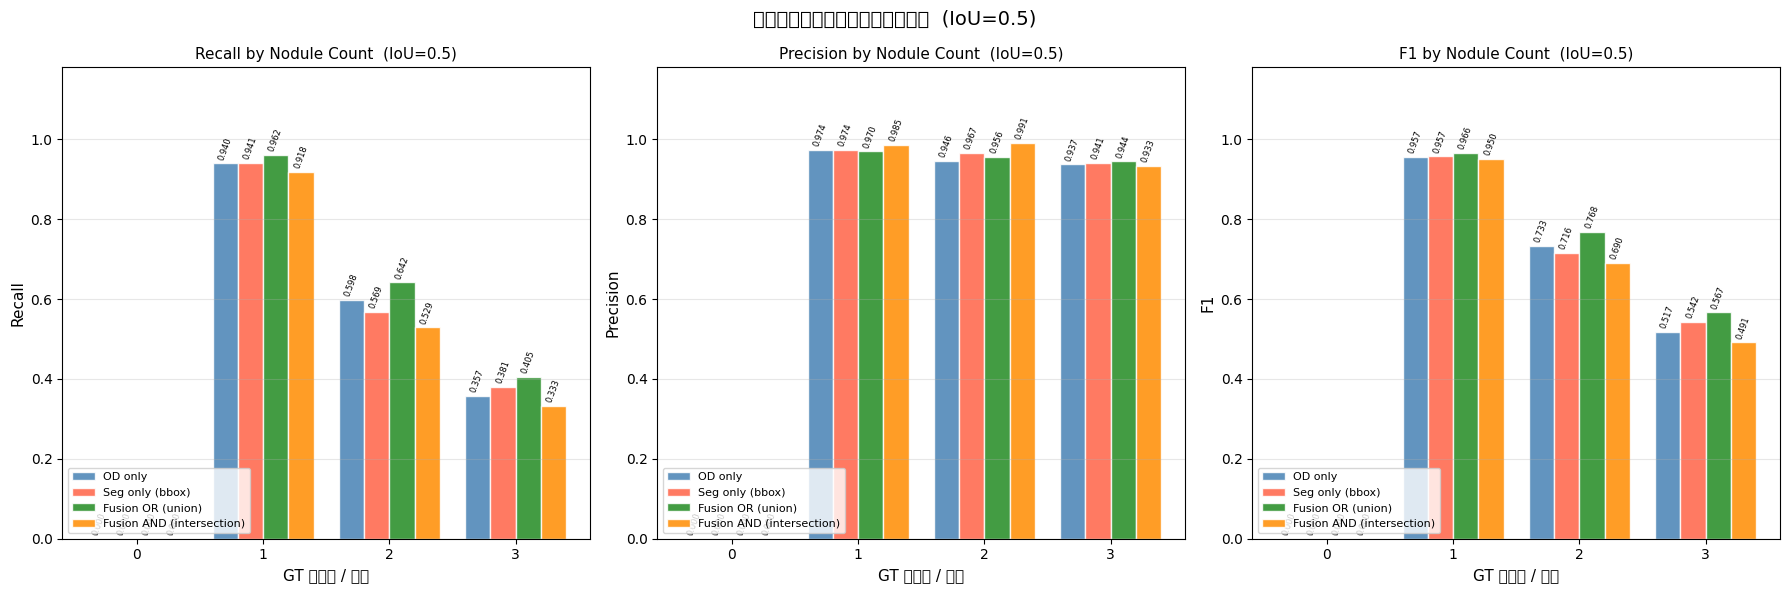

In [247]:
# ============================================================
# 視覺化：各策略 × 結節數量 → Recall / Precision / F1
# ============================================================

metrics_cnt = ['recall', 'precision', 'f1']
metric_titles_cnt = ['Recall', 'Precision', 'F1']

x_pos = np.arange(len(label_order))
width_cnt = 0.2
strat_colors = ['steelblue', 'tomato', 'forestgreen', 'darkorange']

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=False)

for ax, metric, title in zip(axes, metrics_cnt, metric_titles_cnt):
    for si, strategy in enumerate(strategies):
        vals = []
        for lbl in label_order:
            row = cnt_df[(cnt_df['strategy'] == strategy) & (cnt_df['count_label'] == lbl)]
            vals.append(float(row[metric].values[0]) if len(row) > 0 else np.nan)
        offset = (si - 1.5) * width_cnt
        bars = ax.bar(x_pos + offset, vals, width_cnt,
                      label=strategy_labels[strategy],
                      color=strat_colors[si], alpha=0.85, edgecolor='white')
        for bar, v in zip(bars, vals):
            if not np.isnan(v):
                ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                        f'{v:.3f}', ha='center', va='bottom', fontsize=6, rotation=70)

    ax.set_xticks(x_pos)
    ax.set_xticklabels(label_order, fontsize=10)
    ax.set_xlabel('GT 結節數 / 影像', fontsize=11)
    ax.set_ylabel(title, fontsize=11)
    ax.set_title(f'{title} by Nodule Count  (IoU={NODULE_COUNT_IOU})', fontsize=11)
    ax.set_ylim(0, 1.18)
    ax.legend(fontsize=8, loc='lower left')
    ax.grid(axis='y', alpha=0.3)

plt.suptitle(f'不同結節數量對各策略效能之影響  (IoU={NODULE_COUNT_IOU})', fontsize=14)
plt.tight_layout()
plt.show()

/var/folders/52/nxxlf7js5vv8b4p_73c32whw0000gn/T/ipykernel_84922/1937305573.py:30: UserWarning: Glyph 32080 (\N{CJK UNIFIED IDEOGRAPH-7D50}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/52/nxxlf7js5vv8b4p_73c32whw0000gn/T/ipykernel_84922/1937305573.py:30: UserWarning: Glyph 31680 (\N{CJK UNIFIED IDEOGRAPH-7BC0}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/52/nxxlf7js5vv8b4p_73c32whw0000gn/T/ipykernel_84922/1937305573.py:30: UserWarning: Glyph 25976 (\N{CJK UNIFIED IDEOGRAPH-6578}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/52/nxxlf7js5vv8b4p_73c32whw0000gn/T/ipykernel_84922/1937305573.py:30: UserWarning: Glyph 24433 (\N{CJK UNIFIED IDEOGRAPH-5F71}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/52/nxxlf7js5vv8b4p_73c32whw0000gn/T/ipykernel_84922/1937305573.py:30: UserWarning: Glyph 20687 (\N{CJK UNIFIED IDEOGRAPH-50CF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/52/nxxl

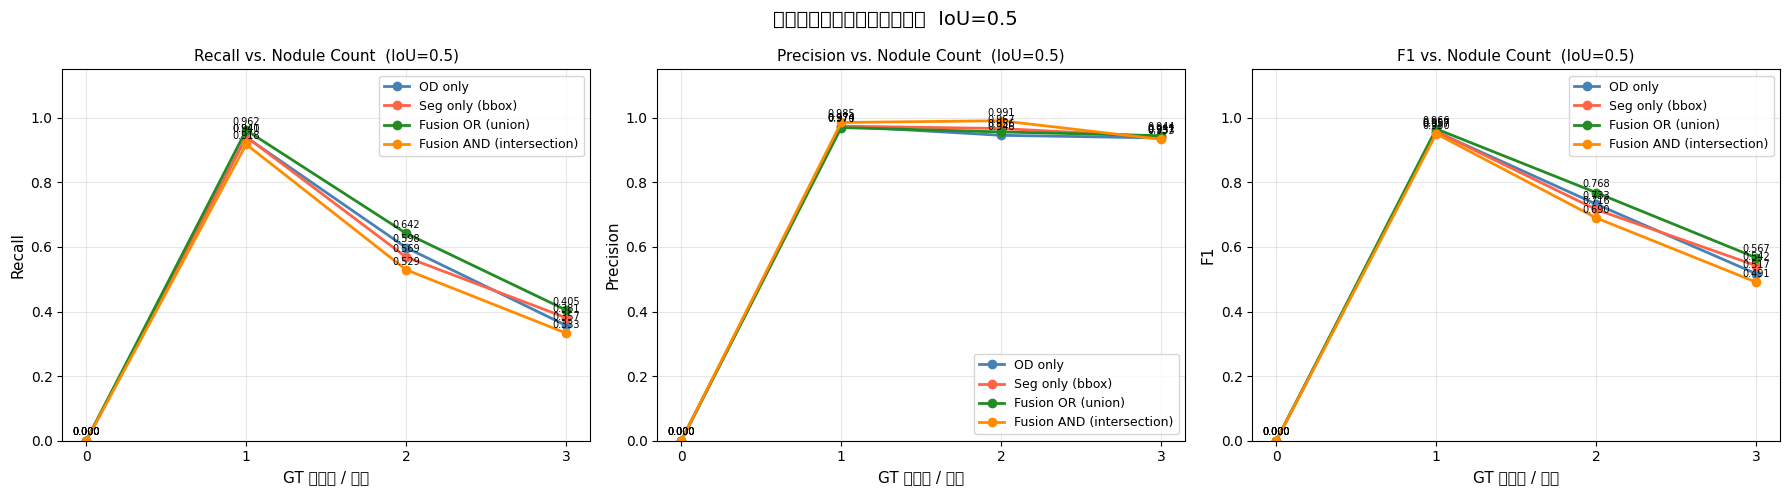

In [248]:
# ============================================================
# 折線圖：以 OR 策略為主，Recall/Precision/F1 vs. 結節數
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, metric, title in zip(axes, metrics_cnt, metric_titles_cnt):
    for si, strategy in enumerate(strategies):
        sub = cnt_df[cnt_df['strategy'] == strategy].copy()
        # 按原始數值排序後取對應 label_order 的值
        sub = sub.sort_values('nodule_count')
        # 合併 ≥N 的多個 row（若有）
        sub_grouped = sub.groupby('count_label', sort=False)[metric].mean().reindex(label_order)
        vals = sub_grouped.values
        ax.plot(label_order, vals, marker='o', markersize=6,
                color=strat_colors[si], linewidth=2,
                label=strategy_labels[strategy])
        for xi, v in enumerate(vals):
            if not np.isnan(v):
                ax.text(xi, v + 0.01, f'{v:.3f}', ha='center', va='bottom', fontsize=7)

    ax.set_xlabel('GT 結節數 / 影像', fontsize=11)
    ax.set_ylabel(title, fontsize=11)
    ax.set_title(f'{title} vs. Nodule Count  (IoU={NODULE_COUNT_IOU})', fontsize=11)
    ax.set_ylim(0, 1.15)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.suptitle(f'結節數量趨勢分析（折線圖）  IoU={NODULE_COUNT_IOU}', fontsize=14)
plt.tight_layout()
plt.show()

## 性別對效能之影響（Male vs. Female）

從 CG 報告檔案取得病人性別，分析各策略在男女病人上的 Recall、Precision、F1 表現。

In [141]:
# ============================================================
# 建立 patient_ID → SEX 對應表（合併所有 CG 報告檔）
# ============================================================
import glob

GENDER_ANALYSIS_IOU = 0.5

report_files = glob.glob(
    '/Users/tony.tu/Desktop/戴承智慧/thyroid_old/data/CG_data/all_reports/*.xlsx'
) + [
    '/Users/tony.tu/Desktop/戴承智慧/thyroid_old/data/CG_data/all_data/12_26_data/report_deid.xlsx',
    '/Users/tony.tu/Desktop/戴承智慧/thyroid_old/data/CG_data/all_data/12_26_data_for_future/report_deid.xlsx',
]

sex_parts = []
for f in report_files:
    df_rep = pd.read_excel(f)
    if 'SEX' in df_rep.columns and 'IDCODE' in df_rep.columns:
        sex_parts.append(df_rep[['IDCODE', 'SEX']].dropna())

sex_map = (
    pd.concat(sex_parts)
    .drop_duplicates('IDCODE')
    .set_index('IDCODE')['SEX']
)

# 分佈確認
print("全體病人性別分佈（報告檔合併後）：")
print(sex_map.value_counts().to_string())

# 驗證 val_df 的 match rate
ref_df_sex = results_by_strategy_iou['or'][GENDER_ANALYSIS_IOU]
all_pids   = ref_df_sex['patient_ID'].unique()
matched_pids = [p for p in all_pids if p in sex_map.index]
print(f"\nVal set patients matched: {len(matched_pids)} / {len(all_pids)}")

全體病人性別分佈（報告檔合併後）：
SEX
F    3983
M    1158

Val set patients matched: 405 / 406


In [142]:
# ============================================================
# 各策略 × 性別 → TP/FP/FN 計數 & 指標
# ============================================================

GENDERS = ['F', 'M']
gender_records = []

for strategy in strategies:
    df = results_by_strategy_iou[strategy][GENDER_ANALYSIS_IOU].copy()
    df['gender'] = df['patient_ID'].map(sex_map)

    for gender in GENDERS:
        grp = df[df['gender'] == gender]
        tp = (grp['match_type'] == 'TP').sum()
        fp = (grp['match_type'] == 'FP').sum()
        fn = (grp['match_type'] == 'FN').sum()
        n_images   = grp['file_name'].nunique()
        n_patients = grp['patient_ID'].nunique()
        recall, precision, f1 = compute_metrics_from_counts(tp, fp, fn)
        tp_iou = grp.loc[grp['match_type'] == 'TP', 'iou'].dropna()
        tp_cd  = grp.loc[grp['match_type'] == 'TP', 'center_distance'].dropna()
        gender_records.append({
            'strategy':    strategy,
            'label':       strategy_labels[strategy],
            'gender':      gender,
            'n_images':    n_images,
            'n_patients':  n_patients,
            'TP': tp, 'FP': fp, 'FN': fn,
            'recall':      recall,
            'precision':   precision,
            'f1':          f1,
            'mean_iou':    tp_iou.mean() if len(tp_iou) else np.nan,
            'mean_cd':     tp_cd.mean()  if len(tp_cd)  else np.nan,
        })

gender_df = pd.DataFrame(gender_records)

# 樞紐表
for metric in ['recall', 'precision', 'f1']:
    pivot = gender_df.pivot_table(index='label', columns='gender',
                                   values=metric, aggfunc='first')[GENDERS]
    print(f"=== {metric.capitalize()} by Gender (IoU={GENDER_ANALYSIS_IOU}) ===")
    display(pivot.round(4))
    print()

# 影像 / 病人數
info = gender_df[gender_df['strategy'] == 'or'][['gender', 'n_images', 'n_patients']]
print("影像 / 病人數：")
display(info.set_index('gender').T)

=== Recall by Gender (IoU=0.5) ===


gender,F,M
label,,
Fusion AND (intersection),0.8501,0.8630
Fusion OR (union),0.9032,0.9148
OD only,0.8770,0.8926
Seg only (bbox),0.8770,0.8852



=== Precision by Gender (IoU=0.5) ===


gender,F,M
label,,
Fusion AND (intersection),0.9840,0.9915
Fusion OR (union),0.9655,0.9802
OD only,0.9702,0.9757
Seg only (bbox),0.9702,0.9876



=== F1 by Gender (IoU=0.5) ===


gender,F,M
label,,
Fusion AND (intersection),0.9122,0.9228
Fusion OR (union),0.9333,0.9464
OD only,0.9213,0.9323
Seg only (bbox),0.9213,0.9336



影像 / 病人數：


gender,F,M
n_images,1192,250
n_patients,330,75


In [ ]:
# ============================================================
# 視覺化：性別 × 策略 → Recall / Precision / F1
# ============================================================

metrics_g    = ['recall', 'precision', 'f1']
metric_titles_g = ['Recall', 'Precision', 'F1']
gender_colors = {'F': '#E87E8A', 'M': '#5B9BD5'}

x_g    = np.arange(len(strategies))
w_g    = 0.3
fig, axes = plt.subplots(1, 3, figsize=(16, 6))

for ax, metric, title in zip(axes, metrics_g, metric_titles_g):
    for gi, gender in enumerate(GENDERS):
        vals = []
        for strategy in strategies:
            row = gender_df[(gender_df['strategy'] == strategy) &
                            (gender_df['gender'] == gender)]
            vals.append(float(row[metric].values[0]) if len(row) > 0 else np.nan)
        offset = (gi - 0.5) * w_g
        bars = ax.bar(x_g + offset, vals, w_g,
                      label=f"{'Female' if gender=='F' else 'Male'} ({gender})",
                      color=gender_colors[gender], alpha=0.85, edgecolor='white')
        for bar, v in zip(bars, vals):
            if not np.isnan(v):
                ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.004,
                        f'{v:.3f}', ha='center', va='bottom', fontsize=8)

    ax.set_xticks(x_g)
    ax.set_xticklabels([strategy_labels[s].replace(' ', '\n') for s in strategies], fontsize=9)
    ax.set_ylabel(title, fontsize=11)
    ax.set_title(f'{title} by Gender  (IoU={GENDER_ANALYSIS_IOU})', fontsize=11)
    ax.set_ylim(0, 1.15)
    ax.legend(fontsize=10)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle(f'性別對各策略效能之影響  (IoU={GENDER_ANALYSIS_IOU})', fontsize=14)
plt.tight_layout()
plt.show()

# ---- 跨 IoU 閾值趨勢（以 OR 策略為例）----
fig2, axes2 = plt.subplots(1, 3, figsize=(16, 5))
for ax, metric, title in zip(axes2, metrics_g, metric_titles_g):
    for gender in GENDERS:
        vals = []
        for iou_thr in all_iou_thresholds:
            df_iou = results_by_strategy_iou['or'][iou_thr].copy()
            df_iou['gender'] = df_iou['patient_ID'].map(sex_map)
            grp = df_iou[df_iou['gender'] == gender]
            tp = (grp['match_type'] == 'TP').sum()
            fp = (grp['match_type'] == 'FP').sum()
            fn = (grp['match_type'] == 'FN').sum()
            r, p, f = compute_metrics_from_counts(tp, fp, fn)
            vals.append({'recall': r, 'precision': p, 'f1': f}[metric])
        ax.plot(all_iou_thresholds, vals, marker='o', markersize=5,
                color=gender_colors[gender], linewidth=2,
                label=f"{'Female' if gender=='F' else 'Male'} ({gender})")
    ax.set_xlabel('IoU Threshold', fontsize=11)
    ax.set_ylabel(title, fontsize=11)
    ax.set_title(f'{title} vs. IoU  [Fusion OR]', fontsize=11)
    ax.set_ylim(0, 1.05)
    ax.legend(fontsize=10)
    ax.grid(alpha=0.3)

plt.suptitle('性別趨勢（Fusion OR，跨 IoU 閾值）', fontsize=13)
plt.tight_layout()
plt.show()